# Does excluding low-extent GFTM modes fix KBM mode selection?

Fusion_PhD-38e9.1. On the KBM Latin hypercubes most GFTM error is mode **selection**, not
identification: a mode close to GS2 is in GFTM's 4-mode spectrum but is not the fastest one.
Hypothesis: spurious fast modes with a short ballooning-angle **extent** win the argmax.

Data: the WIDTH-oracle scan (`wo_*` leaves; `docs/gyro_data_runs.md` in Fusion_PhD), GFTM at fixed
NBASIS_MAX=22 / NXGRID=28, FILTER=0.0, NMODES=4, 24 fixed widths 0.2-4.0, on SPR-045 (`KB_MODELS`)
and M1 (`KB_MODELS_MAST`). GS2 reference: the tail-averaged `pyro_cube_avg` bundles.
Extent: `pyrokinetics.diagnostics.extent.Extent` (branch `feature/extent_diagnostic`, 95% rule),
applied to each cube's `eigenfunctions`.

Sections: (a) the premise measured, (b) extent of spurious vs oracle modes, (c) the cutoff sweep,
plus three checks on the extent numbers. (d), the tearing-parity baseline, is DEFERRED to pyro#594:
FieldLine.compute_linear_tearing_parameter cannot read these GFTM cubes, and parity is not reimplemented here.

**The oracle (mode closest to GS2) consults the answer: it is a bound, never an accuracy.**

## Imports and settings

In [1]:
from pathlib import Path
import os
import warnings
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import pyrokinetics
from pyrokinetics import Pyro
from pyrokinetics.pyroscan import PyroScanGKOutput
from pyrokinetics.dataset_wrapper import DatasetWrapper
from pyrokinetics.diagnostics.extent import Extent
from pyrokinetics.diagnostics.field_line import FieldLine

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
)
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)
print("pyrokinetics", pyrokinetics.__version__)

analysis_name = "kbm_extent_filter"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
run_template = "Runs"
project = "LATIN_HYPERCUBE"
cases = {"SPR-045": "SPR-045", "M1": "M1"}  # database label -> case directory
scan_information = {"GFTM": "kbm_8d/wo_{width}", "GS2": "kbm_8d"}
output_dir = {"GFTM": "pyro_cube", "GS2": "pyro_cube_avg"}  # GS2: tail-averaged reference
output_file = "cube.nc"
gs2_input_file = "gs2.in"   # per-run GS2 input (scan dir / sample name / this); pyro reads gs2.out.nc beside it
widths = ["w0p2000", "w0p2297", "w0p2639", "w0p3031", "w0p3482", "w0p4000", "w0p4595",
          "w0p5279", "w0p6063", "w0p6965", "w0p8000", "w0p9000", "w1p0000", "w1p1000",
          "w1p2000", "w1p3000", "w1p4000", "w1p5000", "w1p6000", "w1p9218", "w2p3083",
          "w2p7726", "w3p3302", "w4p0000"]
width_value = {w: float(w[1:].replace("p", ".")) for w in widths}
expected_resolution = {"nbasis_used": 22, "nxgrid_used": 28}

fraction = 0.95                             # Extent's rule: theta range holding 95% of |Re field|^2
fields = ["phi", "apar"]                    # phi selects; apar reported alongside
cutoffs = np.round(np.arange(0, 12.01, 0.25), 2)       # absolute extent cutoff [rad]
rel_cutoffs = np.round(np.arange(0, 1.001, 0.05), 2)   # fraction of the case's largest unstable-mode extent
edge_amplitude = 0.05    # check 1: |phi| at the theta-grid edge above this fraction of its peak
delta_lim = 0.2          # fig 2 colour range for the medlog change (clipped; misses-dominate cells are grey)
example_width = "w1p0000"
n_examples = 3

pyrokinetics 0.9.2.dev30+gfa3864e7


## Load data

One `PyroScanGKOutput` per (database, width), read from the cube's netCDF. The extent branch has no
`PyroHypercube` or GFTM reader, so the cube is loaded as the scan's gk_output object, which carries
units. `Extent` adds `extent(sample, field, mode)` and `bounds(..., bound=lo/hi)` in place.

In [2]:
gs2, gftm = {}, {}
for db, case in cases.items():
    gs2[db] = PyroScanGKOutput.from_netcdf(
        data_root / "GS2" / run_template / project / case / scan_information["GS2"] / output_dir["GS2"] / output_file)
    Extent(gs2[db], fraction=fraction)   # GS2 extents: used by the GFTM-vs-GS2 extent comparison at the end
    for w in widths:
        out = PyroScanGKOutput.from_netcdf(
            data_root / "GFTM" / run_template / project / case / scan_information["GFTM"].format(width=w)
            / output_dir["GFTM"] / output_file)
        Extent(out, fraction=fraction)
        gftm[db, w] = out
    print(db, "GS2 samples", gs2[db].data.sizes["sample"], "| GFTM cubes", len(widths))

SPR-045 GS2 samples 300 | GFTM cubes 24
M1 GS2 samples 300 | GFTM cubes 24


## Calculate and select

Conventions, checked rather than assumed: both codes' growth rates are in the same pyrokinetics
units; each cube's audited resolution (`*_used`, from `out.gftm.localdump`) is the requested one.

Per case, GFTM returns 4 modes. A **selector** takes the argmax growth rate over `mode` among
*unstable* modes (gamma > 0) that pass its gate. A case where no unstable mode passes is a **MISS**:
it stays in the population with gamma_sel = 0, so its |log10| error is +inf and its absolute error is
gamma_GS2. Misses therefore move the median, and medlog becomes inf once they are the majority.

Population: cases whose GS2 growth rate is finite and positive (the same cases for every selector
and width, so every comparison is paired).

- `dominant`: no gate (c = 0; the current argmax over unstable modes).
- `oracle`: the unstable mode with the smallest |log10(gamma/gamma_GS2)| -- a bound.
- `extent >= c`: absolute cutoff on the 95% extent of phi (apar alongside).
- `extent >= r * max extent`: relative cutoff on the case's own longest unstable mode.

In [3]:
def mag(v):
    return np.asarray(getattr(v.data, "magnitude", v.data))


def select(gam, keep):
    # argmax growth over 'mode' among unstable modes passing `keep`; 0 where none passes (a MISS)
    g = np.where(keep & (gam > 0), gam, -np.inf)
    idx = g.argmax(axis=1)
    return np.where(np.isfinite(g.max(axis=1)), gam[np.arange(len(gam)), idx], 0.0), idx


def score(g_sel, g_ref):
    with np.errstate(divide="ignore"):
        log_err = np.abs(np.log10(g_sel / g_ref))
    return np.median(np.abs(g_sel - g_ref)), np.median(log_err), int((g_sel == 0).sum())


rows, sweep, cases_data = [], [], {}
for (db, w), out in gftm.items():
    d, ref = out.data, gs2[db].data
    assert str(d.growth_rate.data.units) == str(ref.growth_rate.data.units), "normalisations differ"
    for var, value in expected_resolution.items():
        assert (mag(d[var]) == value).all(), f"{db}/{w}: {var} is not {value}"
    assert np.allclose(mag(d.width_used), width_value[w])

    ref_by_name = dict(zip(ref.sample_name.values, mag(ref.growth_rate)))
    g_ref_all = np.array([ref_by_name.get(n, np.nan) for n in d.sample_name.values])
    ok = np.isfinite(g_ref_all) & (g_ref_all > 0)
    g_ref = g_ref_all[ok]
    gam = mag(d.growth_rate.transpose("sample", "mode"))[ok]
    ext = {f: mag(d.extent.sel(field=f).transpose("sample", "mode"))[ok] for f in fields}
    theta = d.theta.values
    phi = mag(d.eigenfunctions.sel(field="phi").transpose("sample", "theta", "mode"))[ok]

    unstable = gam > 0
    g_dom, i_dom = select(gam, True)
    with np.errstate(divide="ignore", invalid="ignore"):
        dist = np.where(unstable, np.abs(np.log10(gam / g_ref[:, None])), np.inf)
    i_orc = dist.argmin(axis=1)
    g_orc = np.where(unstable.any(axis=1), gam[np.arange(len(gam)), i_orc], 0.0)

    # check 1: 95% bounds within one grid spacing of the edge, or |phi| at the edge above edge_amplitude of peak
    lo, hi = (mag(d.bounds.sel(field="phi", bound=b).transpose("sample", "mode"))[ok] for b in ("lo", "hi"))
    dtheta = theta[1] - theta[0]
    at_edge = (lo <= theta[0] + dtheta) | (hi >= theta[-1] - dtheta)
    edge_amp = np.maximum(np.abs(phi[:, 0]), np.abs(phi[:, -1])) / np.abs(phi).max(axis=1)

    # check 2: rotate each eigenfunction so its peak is real, recompute Extent
    e = mag(d.eigenfunctions)
    axis = d.eigenfunctions.get_axis_num("theta")
    peak = np.take_along_axis(e, np.abs(e).argmax(axis=axis, keepdims=True), axis=axis)
    rot = DatasetWrapper(data_vars={"eigenfunctions": d.eigenfunctions.copy(data=e * np.exp(-1j * np.angle(peak)))})
    Extent(rot, fraction=fraction)
    with np.errstate(divide="ignore", invalid="ignore"):
        phase_change = {f: np.abs(mag(rot.data.extent.sel(field=f).transpose("sample", "mode"))[ok] - ext[f]) / ext[f]
                        for f in fields}
    del rot

    differ = i_dom != i_orc
    with np.errstate(divide="ignore"):
        err_dom, err_orc = np.abs(np.log10(g_dom / g_ref)), np.abs(np.log10(g_orc / g_ref))
    r = np.arange(len(gam))
    row = dict(db=db, width=width_value[w], n=int(ok.sum()), n_gs2_stable_or_nan=int((~ok).sum()),
               differ=int(differ.sum()),
               medlog_dom=score(g_dom, g_ref)[1], medlog_orc=score(g_orc, g_ref)[1],
               medAE_dom=score(g_dom, g_ref)[0], medAE_orc=score(g_orc, g_ref)[0],
               medlog_dom_agree=np.median(err_dom[~differ]), medlog_dom_differ=np.median(err_dom[differ]),
               medlog_orc_differ=np.median(err_orc[differ]),
               share_err_from_differ=err_dom[differ & np.isfinite(err_dom)].sum() / err_dom[np.isfinite(err_dom)].sum(),
               unstable_modes=int(unstable.sum()), unstable_nan_extent=int((unstable & ~np.isfinite(ext["phi"])).sum()),
               frac_bounds_at_edge=at_edge[unstable].mean(), frac_edge_amp=(edge_amp[unstable] > edge_amplitude).mean(),
               **{f"phase_{f}_median_rel_change": np.nanmedian(phase_change[f][unstable]) for f in fields},
               **{f"phase_{f}_frac_over_10pct": (phase_change[f][unstable] > 0.1).mean() for f in fields})
    for f in fields:
        a, b = ext[f][r, i_dom][differ], ext[f][r, i_orc][differ]
        row[f"{f}_ext_dom_shorter"] = (a < b).mean()
        row[f"{f}_ext_ratio_median"] = np.median(a / b)
    rows.append(row)

    longest = np.nanmax(np.where(unstable, ext["phi"], np.nan), axis=1, initial=0)
    for f in fields:
        for kind, grid in (("abs", cutoffs), ("rel", rel_cutoffs)):
            for c in grid:
                threshold = c if kind == "abs" else c * longest[:, None]
                keep = (ext[f] >= threshold) | (c == 0)   # c = 0 keeps NaN-extent modes: exactly `dominant`
                medAE, medlog, miss = score(select(gam, keep)[0], g_ref)
                sweep.append(dict(db=db, width=width_value[w], field=f, kind=kind, cutoff=c,
                                  medlog=medlog, medAE=medAE, miss=miss, n=len(g_ref)))
    cases_data[db, w] = dict(names=d.sample_name.values[ok], gam=gam, g_ref=g_ref, i_dom=i_dom, i_orc=i_orc,
                             ext=ext, err_dom=err_dom, differ=differ)

summary = pd.DataFrame(rows)
sweep = pd.DataFrame(sweep)

### (a) The premise, measured

`differ`: cases where the oracle mode is not the dominant one. `share_err_from_differ`: fraction of
the dominant arm's total |log10| error carried by those cases.

In [4]:
pd.set_option("display.width", 250, "display.max_columns", 40)
print(summary[["db", "width", "n", "n_gs2_stable_or_nan", "differ", "medlog_dom", "medlog_orc",
               "medlog_dom_agree", "medlog_dom_differ", "medlog_orc_differ", "share_err_from_differ",
               "medAE_dom", "medAE_orc"]].round(4).to_string(index=False))
print(summary.groupby("db")[["differ", "share_err_from_differ"]].agg(["min", "median", "max"]).round(3))

     db  width   n  n_gs2_stable_or_nan  differ  medlog_dom  medlog_orc  medlog_dom_agree  medlog_dom_differ  medlog_orc_differ  share_err_from_differ  medAE_dom  medAE_orc
SPR-045 0.2000 220                   80      96      0.3472      0.2005            0.2011             0.7726             0.2001                 0.6771     0.0427     0.0131
SPR-045 0.2297 220                   80     103      0.3039      0.1271            0.1183             0.7430             0.1315                 0.7327     0.0273     0.0088
SPR-045 0.2639 220                   80     114      0.2821      0.0998            0.1085             0.6815             0.0922                 0.7625     0.0338     0.0073
SPR-045 0.3031 220                   80     125      0.2914      0.0722            0.0727             0.6023             0.0717                 0.8018     0.0374     0.0064
SPR-045 0.3482 220                   80     121      0.2841      0.0765            0.0767             0.5965             0.0763        

### Checks on the extent numbers (grid edge, phase, NaN extents)

In [5]:
print(summary[["db", "width", "unstable_modes", "unstable_nan_extent", "frac_bounds_at_edge", "frac_edge_amp",
               ] + [f"phase_{f}_{k}" for f in fields for k in ("median_rel_change", "frac_over_10pct")]].round(4).to_string(index=False))

     db  width  unstable_modes  unstable_nan_extent  frac_bounds_at_edge  frac_edge_amp  phase_phi_median_rel_change  phase_phi_frac_over_10pct  phase_apar_median_rel_change  phase_apar_frac_over_10pct
SPR-045 0.2000             813                    0                  0.0         0.0000                          0.0                        0.0                        0.0105                      0.2337
SPR-045 0.2297             814                    0                  0.0         0.0000                          0.0                        0.0                        0.0215                      0.2961
SPR-045 0.2639             826                    0                  0.0         0.0000                          0.0                        0.0                        0.0164                      0.2676
SPR-045 0.3031             837                    0                  0.0         0.0000                          0.0                        0.0                        0.0208                   

### (b) Extent of the spurious dominant mode vs the oracle mode, where they differ

In [6]:
print(summary[["db", "width", "differ"] + [f"{f}_{k}" for f in fields for k in ("ext_dom_shorter", "ext_ratio_median")]]
      .round(3).to_string(index=False))
for db in cases:
    for f in fields:
        a = np.concatenate([v["ext"][f][np.arange(len(v["gam"])), v["i_dom"]][v["differ"]] for (d_, w), v in cases_data.items() if d_ == db])
        b = np.concatenate([v["ext"][f][np.arange(len(v["gam"])), v["i_orc"]][v["differ"]] for (d_, w), v in cases_data.items() if d_ == db])
        print(f"{db} {f}: pooled over widths n={len(a)}, dominant shorter in {np.mean(a < b):.3f}, "
              f"median ratio dom/orc {np.nanmedian(a / b):.3f}")

     db  width  differ  phi_ext_dom_shorter  phi_ext_ratio_median  apar_ext_dom_shorter  apar_ext_ratio_median
SPR-045  0.200      96                0.156                 1.396                 0.844                  0.505
SPR-045  0.230     103                0.165                 1.599                 0.806                  0.432
SPR-045  0.264     114                0.123                 1.592                 0.781                  0.453
SPR-045  0.303     125                0.176                 1.674                 0.792                  0.435
SPR-045  0.348     121                0.231                 1.514                 0.777                  0.444
SPR-045  0.400     116                0.267                 1.610                 0.716                  0.495
SPR-045  0.460      90                0.378                 1.207                 0.633                  0.620
SPR-045  0.528      73                0.521                 0.980                 0.589                  0.797
S

### (c) The cutoff sweep

For each (database, width): the cutoff minimising medlog, its miss count and change vs c = 0,
next to the oracle bound. The parity baseline (d) is deferred to pyro#594.

In [7]:
best = (sweep[np.isfinite(sweep.medlog)].sort_values("medlog").groupby(["db", "field", "kind", "width"]).head(1)
        .set_index(["db", "field", "kind", "width"]).sort_index())
base = sweep[sweep.cutoff == 0].set_index(["db", "field", "kind", "width"])
best = best.assign(medlog_c0=base.medlog, medAE_c0=base.medAE)
best = best.assign(d_medlog=best.medlog - best.medlog_c0)
best = best.join(summary.set_index(["db", "width"])[["medlog_orc"]])
for f in fields:
  print(f"--- {f}, absolute cutoff ---")
  print(best.loc[(slice(None), f, "abs"), ["cutoff", "medlog", "medlog_c0", "d_medlog", "medAE", "medAE_c0",
                                             "miss", "medlog_orc"]].round(4).to_string())
print("--- phi and apar, relative cutoff ---")
print(best.loc[(slice(None), slice(None), "rel"), ["cutoff", "medlog", "medlog_c0", "d_medlog", "miss"]].round(4).to_string())
for f in fields:
    for kind in ("abs", "rel"):
        b = best.loc[(slice(None), f, kind)]
        wins = b[b.d_medlog < 0]
        print(f"{f}/{kind}: cells where some cutoff lowers medlog: "
              + ", ".join(f"{db} {len(wins.loc[db]) if db in wins.index.get_level_values(0) else 0}/{len(widths)}" for db in cases)
              + f" | largest improvement: " + ", ".join(f"{db} {b.loc[db].d_medlog.min():+.4f}" for db in cases))

--- phi, absolute cutoff ---
                           cutoff  medlog  medlog_c0  d_medlog   medAE  medAE_c0  miss  medlog_orc
db      field kind width                                                                          
M1      phi   abs  0.2000    1.50  0.1863     0.1950   -0.0087  0.0676    0.0695     2      0.0961
                   0.2297    0.50  0.1720     0.1720    0.0000  0.0551    0.0551     0      0.0828
                   0.2639    1.50  0.1585     0.1623   -0.0038  0.0453    0.0456     1      0.0735
                   0.3031    1.50  0.1245     0.1259   -0.0013  0.0416    0.0416     0      0.0575
                   0.3482    1.50  0.1407     0.1407    0.0000  0.0428    0.0428     0      0.0470
                   0.4000    1.25  0.1307     0.1307    0.0000  0.0391    0.0391     0      0.0461
                   0.4595    0.75  0.0913     0.0913    0.0000  0.0331    0.0331     0      0.0477
                   0.5279    1.50  0.0847     0.0847    0.0000  0.0317    0.0317

## Plot

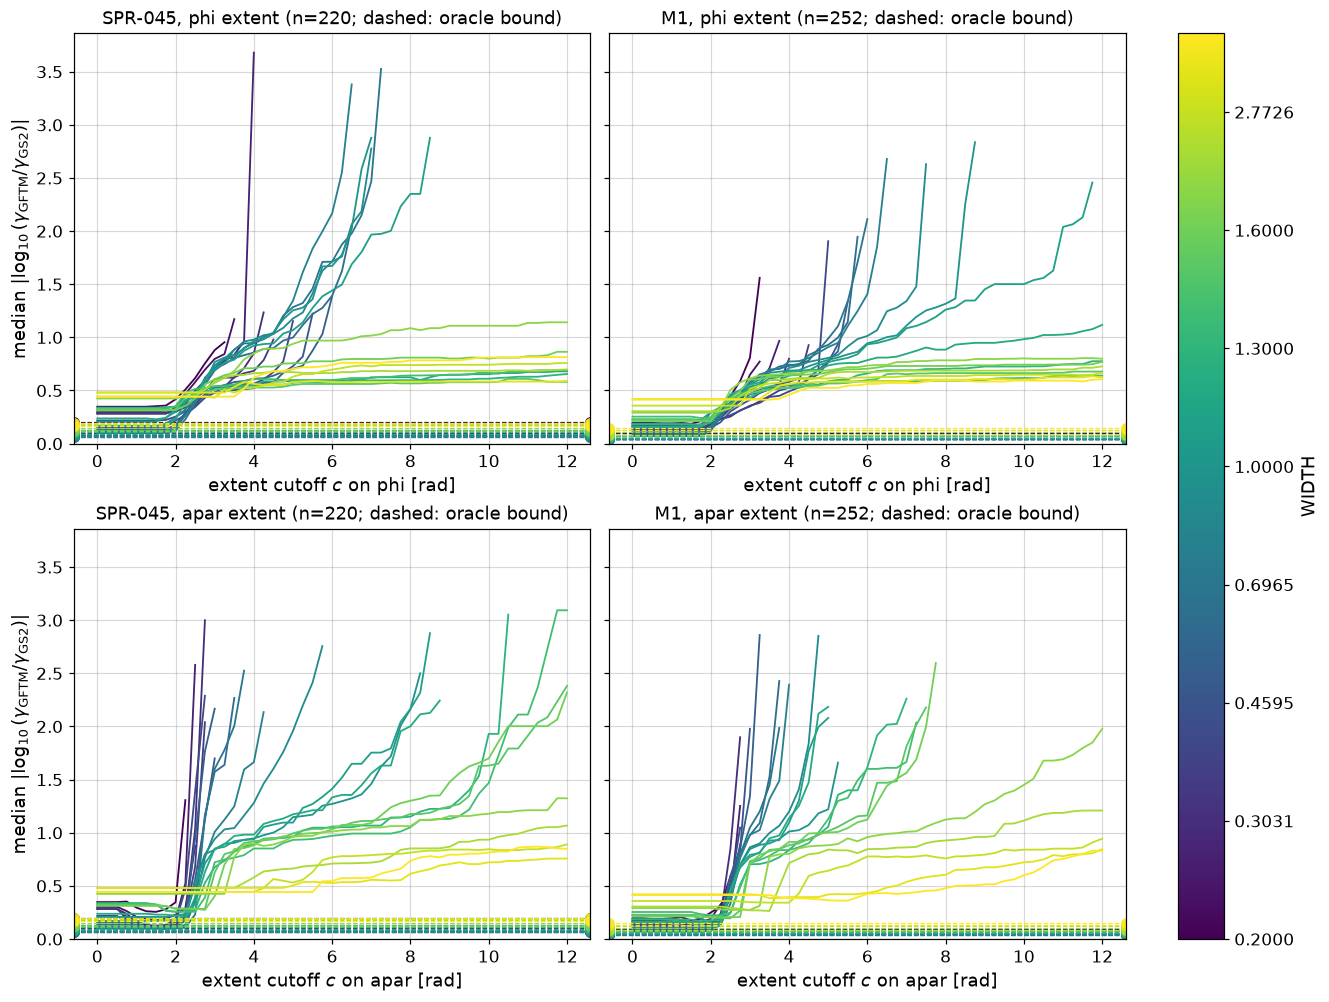

In [8]:
cmap = plt.get_cmap("viridis")
colour = {w: cmap(i / (len(widths) - 1)) for i, w in enumerate(widths)}

fig1, axes1 = plt.subplots(len(fields), 2, figsize=(12, 9), sharey=True)
for ax, (f, db) in zip(axes1.flat, [(f, db) for f in fields for db in cases]):
    for w in widths:
        s = sweep[(sweep.db == db) & (sweep.width == width_value[w]) & (sweep.field == f) & (sweep.kind == "abs")]
        ax.plot(s.cutoff, s.medlog, color=colour[w], marker="", lw=1.2)
        ax.axhline(summary[(summary.db == db) & (summary.width == width_value[w])].medlog_orc.item(),
                   color=colour[w], ls="--", lw=0.8)
    ax.set(xlabel=f"extent cutoff $c$ on {f} [rad]", title=f"{db}, {f} extent (n={s.n.iloc[0]}; dashed: oracle bound)")
for ax in axes1[:, 0]:
    ax.set(ylabel=r"median $|\log_{10}(\gamma_{\rm GFTM}/\gamma_{\rm GS2})|$", ylim=(0, None))
fig1.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(0, len(widths) - 1), cmap=cmap), ax=axes1,
              ticks=range(0, len(widths), 3), label="WIDTH").ax.set_yticklabels([widths[i][1:].replace("p", ".") for i in range(0, len(widths), 3)])
plt.show()

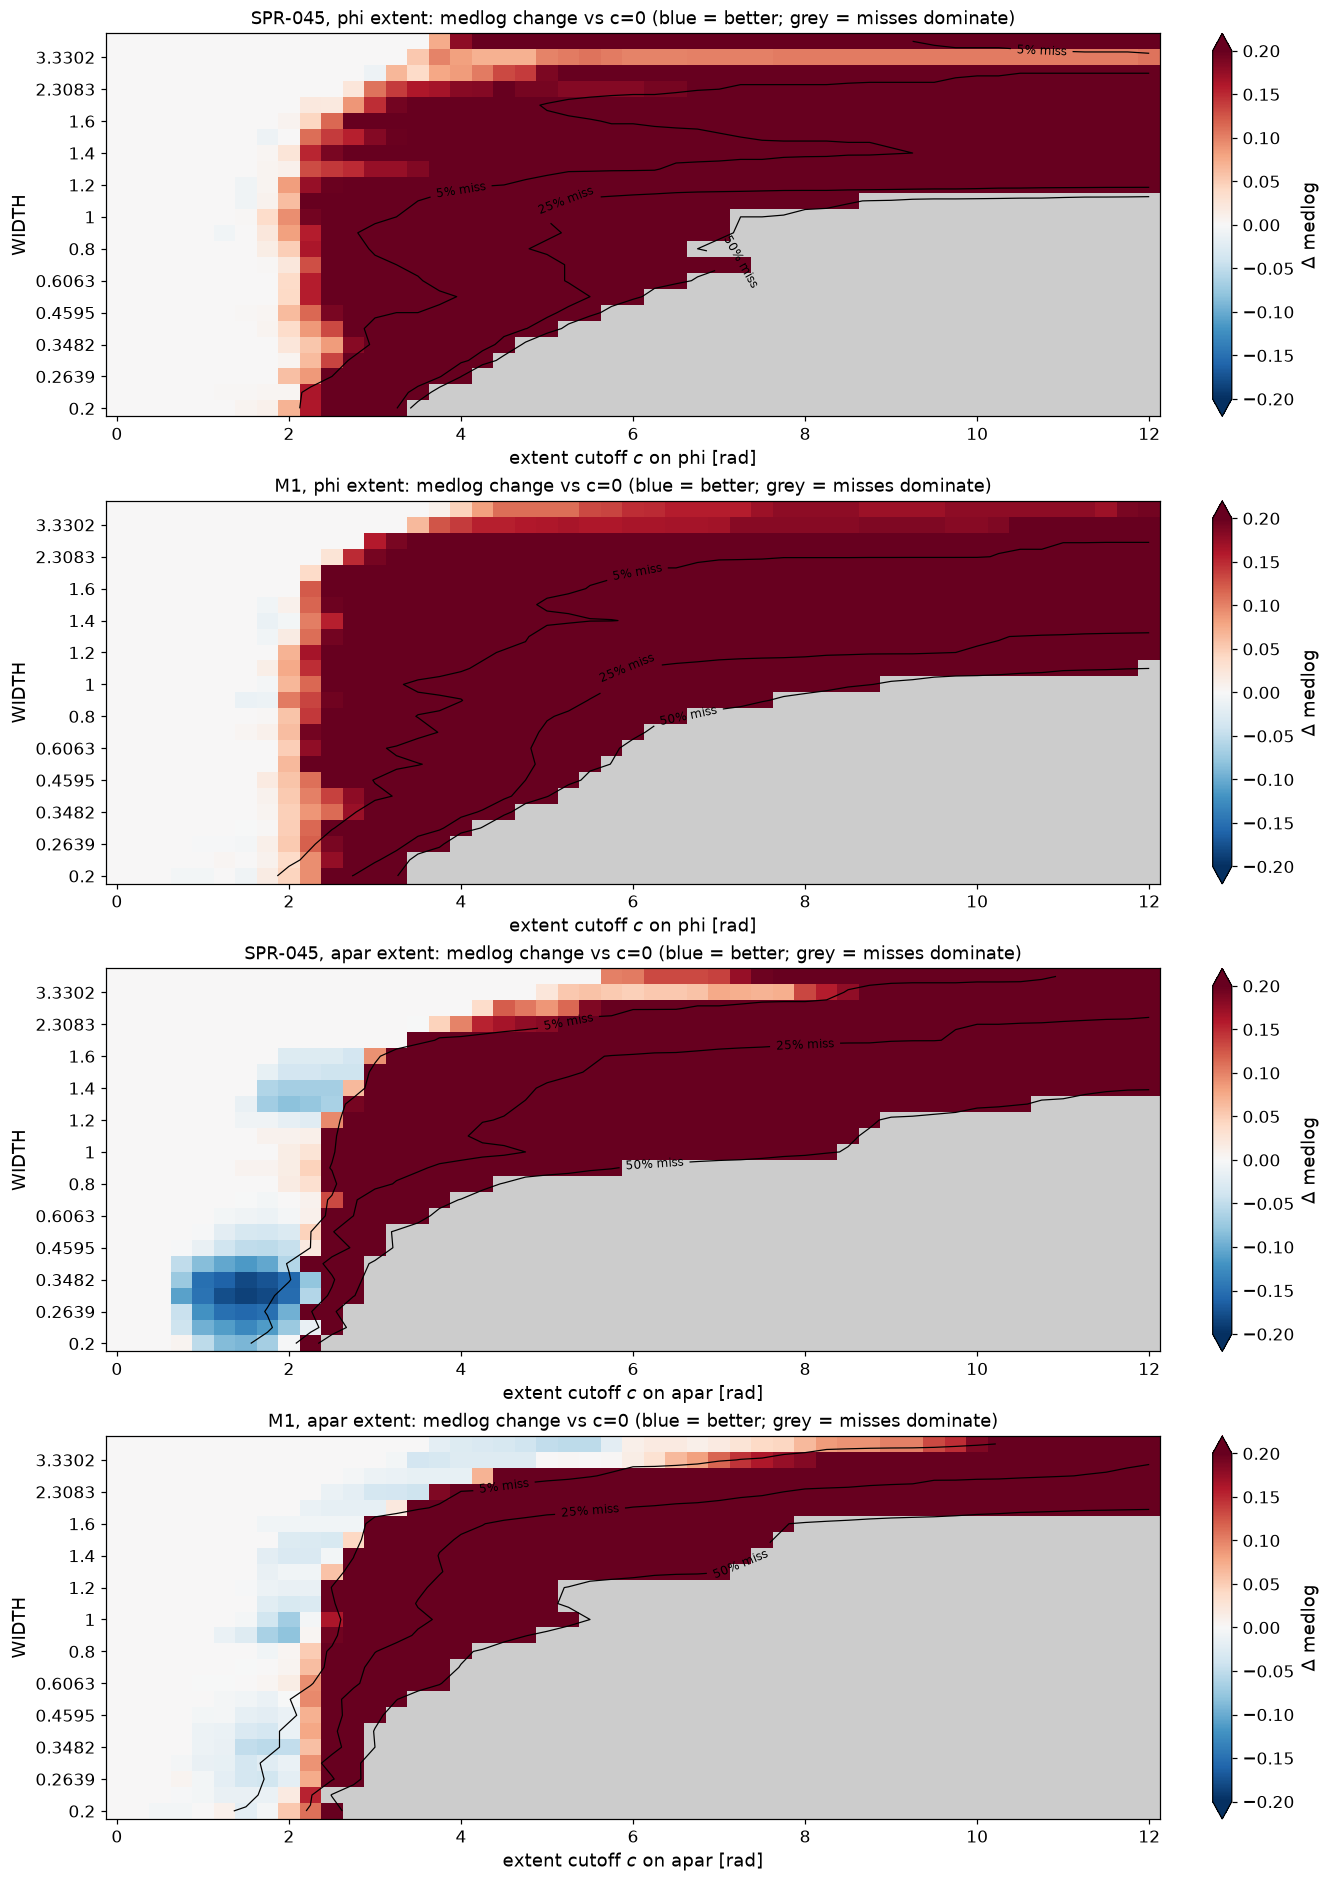

In [9]:
fig2, axes2 = plt.subplots(2 * len(fields), 1, figsize=(12, 17))
for row, (f, db) in enumerate([(f, db) for f in fields for db in cases]):
    s = sweep[(sweep.db == db) & (sweep.field == f) & (sweep.kind == "abs")]
    grid = s.pivot(index="width", columns="cutoff", values="medlog")
    delta = grid.sub(grid[0.0], axis=0)
    miss = s.pivot(index="width", columns="cutoff", values="miss") / s.n.iloc[0]
    norm = TwoSlopeNorm(0, -delta_lim, delta_lim)
    y = np.arange(len(widths))
    m = axes2[row].pcolormesh(cutoffs, y, np.ma.masked_invalid(delta.values), cmap="RdBu_r", norm=norm, shading="nearest")
    cs = axes2[row].contour(cutoffs, y, miss.values, levels=[0.05, 0.25, 0.5], colors="k", linewidths=0.8)
    axes2[row].clabel(cs, fmt=lambda v: f"{v:.0%} miss", fontsize=8)
    axes2[row].set(xlabel=f"extent cutoff $c$ on {f} [rad]", ylabel="WIDTH", yticks=y[::2],
                      yticklabels=[f"{v:g}" for v in grid.index[::2]],
                      title=f"{db}, {f} extent: medlog change vs c=0 (blue = better; grey = misses dominate)")
    axes2[row].set_facecolor("0.8")
    axes2[row].grid(False)
    fig2.colorbar(m, ax=axes2[row], label=r"$\Delta$ medlog", extend="both")
plt.show()

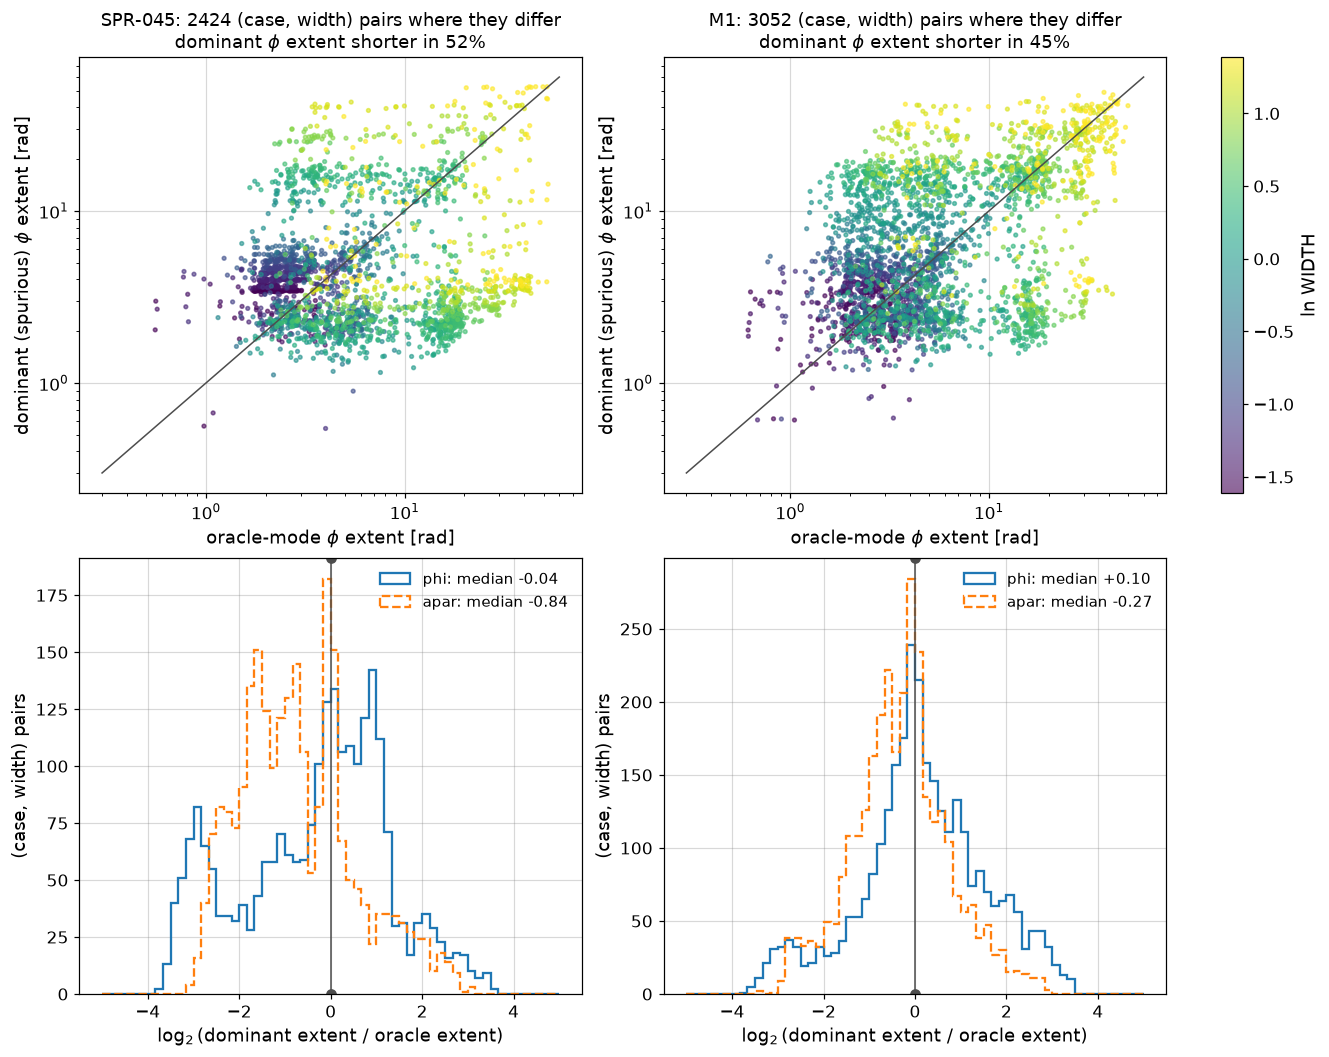

In [10]:
fig3, axes3 = plt.subplots(2, 2, figsize=(12, 9.5))
for col, db in enumerate(cases):
    pts = {f: [] for f in fields}
    for w in widths:
        v = cases_data[db, w]
        r = np.arange(len(v["gam"]))
        for f in fields:
            pts[f].append((v["ext"][f][r, v["i_dom"]][v["differ"]], v["ext"][f][r, v["i_orc"]][v["differ"]],
                           np.full(v["differ"].sum(), width_value[w])))
    a, b, wv = (np.concatenate(x) for x in zip(*pts["phi"]))
    sc = axes3[0, col].scatter(b, a, c=np.log(wv), cmap=cmap, s=6, alpha=0.6)
    axes3[0, col].plot([0.3, 60], [0.3, 60], color="0.3", lw=1, marker="")
    axes3[0, col].set(xscale="log", yscale="log", xlabel=r"oracle-mode $\phi$ extent [rad]",
                      ylabel=r"dominant (spurious) $\phi$ extent [rad]",
                      title=f"{db}: {len(a)} (case, width) pairs where they differ\n"
                            f"dominant $\\phi$ extent shorter in {np.mean(a < b):.0%}")
    for f, ls in zip(fields, ("-", "--")):
        a_, b_, _ = (np.concatenate(x) for x in zip(*pts[f]))
        axes3[1, col].hist(np.log2(a_ / b_), bins=60, range=(-5, 5), histtype="step", ls=ls, lw=1.5,
                           label=f"{f}: median {np.nanmedian(np.log2(a_ / b_)):+.2f}")
    axes3[1, col].axvline(0, color="0.3", lw=1)
    axes3[1, col].set(xlabel=r"$\log_2$(dominant extent / oracle extent)", ylabel="(case, width) pairs")
    axes3[1, col].legend()
fig3.colorbar(sc, ax=axes3[0, :], label="ln WIDTH")
plt.show()

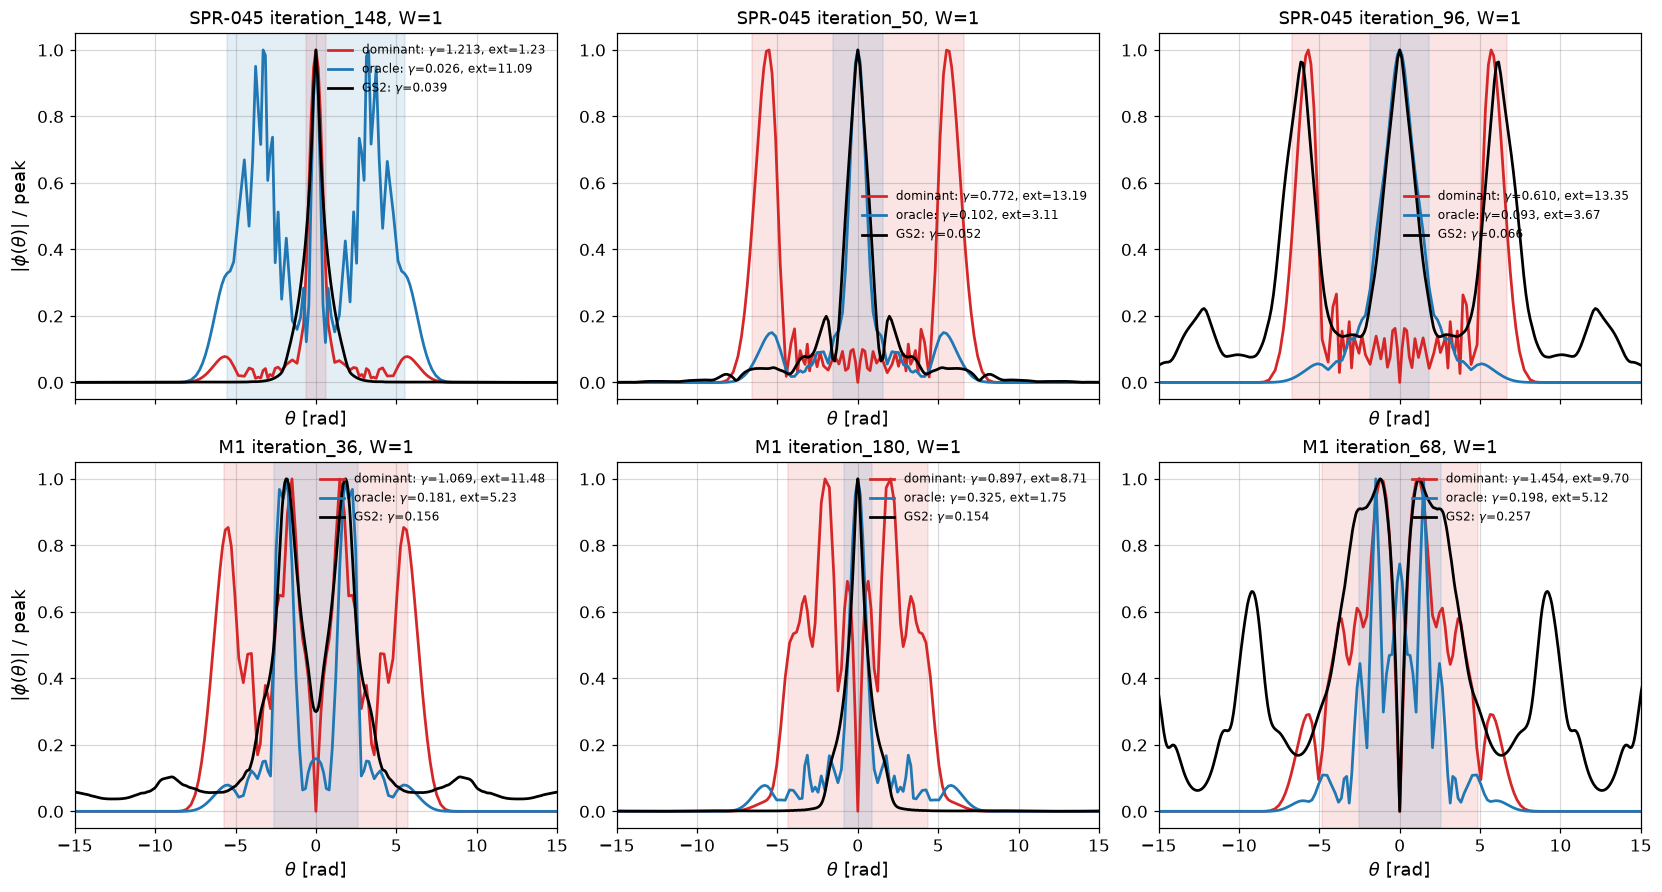

In [11]:
fig4, axes4 = plt.subplots(len(cases), n_examples, figsize=(15, 8), sharex=True)
for row, db in enumerate(cases):
    v = cases_data[db, example_width]
    d = gftm[db, example_width].data
    ref = gs2[db].data
    # largest dominant-mode errors among cases with GS2 gamma above the median (avoids near-marginal cases)
    picks = np.where(v["differ"] & np.isfinite(v["err_dom"]) & (v["g_ref"] >= np.median(v["g_ref"])))[0]
    picks = picks[np.argsort(v["err_dom"][picks])[::-1][:n_examples]]
    for ax, k in zip(axes4[row], picks):
        name = v["names"][k]
        s = int(np.where(d.sample_name.values == name)[0][0])
        for label, m, c in (("dominant", v["i_dom"][k], "C3"), ("oracle", v["i_orc"][k], "C0")):
            e = np.abs(mag(d.eigenfunctions.sel(field="phi").isel(sample=s, mode=m)))
            lo, hi = mag(d.bounds.sel(field="phi").isel(sample=s, mode=m))
            ax.plot(d.theta, e / e.max(), color=c, marker="", label=f"{label}: $\\gamma$={v['gam'][k, m]:.3f}, ext={hi - lo:.2f}")
            ax.axvspan(lo, hi, color=c, alpha=0.12)
        sg = int(np.where(ref.sample_name.values == name)[0][0])
        e = np.abs(mag(ref.eigenfunctions.sel(field="phi").isel(sample=sg)))
        ax.plot(ref.theta, e / e.max(), color="black", marker="", label=f"GS2: $\\gamma$={v['g_ref'][k]:.3f}")
        ax.set(title=f"{db} {name}, W={width_value[example_width]:g}", xlabel=r"$\theta$ [rad]", xlim=(-15, 15))
        ax.legend(fontsize=8)
    axes4[row, 0].set(ylabel=r"$|\phi(\theta)|$ / peak")
plt.show()

## Save

In [12]:
output_dir = ROOT / "Plots" / analysis_name
output_dir.mkdir(parents=True, exist_ok=True)
fig1.savefig(output_dir / "fig1_medlog_vs_cutoff.png")
fig2.savefig(output_dir / "fig2_heatmap_width_cutoff.png")
fig3.savefig(output_dir / "fig3_extent_spurious_vs_oracle.png")
fig4.savefig(output_dir / "fig4_example_eigenfunctions.png")

## Interpretation

See the Fusion_PhD `results/kbm_extent_filter/README.md` for the verdict written from this notebook's
executed output. Limitations: the oracle consults GS2 and is a bound; extents come from pyro's fixed
output theta grid (+-9 pi), so edge-limited modes (check 1) give lower bounds; |Re(phi)| makes extent
phase-dependent (check 2), and the apar extent strongly so; the tearing-parity baseline is deferred
to pyro#594.

# Does GFTM's own parity filter (FILTER=0.5) fix KBM mode selection?

Fusion_PhD-38e9.2. The extent cutoff above did not separate spurious modes. GFTM has its own solver-side
parity gate: `FILTER` (gftm_LS.f90:582 flags TM_PARITY when phi_norm_even < FILTER, :325 discards it).
qp5.20 found FILTER=0.5 cut gftm_fw04's medAE on SPR-045 0.048 -> 0.013, at one width. Here the whole width axis.

Data: the `wo_f05_*` leaves, identical to `wo_*` (NBASIS_MAX 22, NXGRID 28, NMODES 4, FIND_WIDTH F, 24 widths)
with **FILTER=0.5 the only difference** (`wo_*` run FILTER=0.0). The parity filter is GFTM's own, not reimplemented here.

Scoring, per (database, width), **paired on the same GS2-unstable cases** as the sections above: the dominant
mode (argmax growth rate over `mode` among unstable modes) for FILTER=0.0 and FILTER=0.5, medlog and medAE.
A case with no unstable mode returned is a **MISS**: kept in the population as +inf log error (and |gamma_GS2| absolute
error), counted. The FILTER=0.0 oracle (mode closest to GS2) is a **bound, never an accuracy**.

## FILTER=0.5: settings and data

In [13]:
scan_information_f05 = "kbm_8d/wo_f05_{width}"
filter_requested = 0.5

gftm05 = {}
for db, case in cases.items():
    for w in widths:
        out = PyroScanGKOutput.from_netcdf(
            data_root / "GFTM" / run_template / project / case / scan_information_f05.format(width=w)
            / "pyro_cube" / output_file)
        Extent(out, fraction=fraction)   # used by the extent-on-top-of-FILTER=0.5 section at the end
        gftm05[db, w] = out
print("FILTER=0.5 cubes loaded:", len(gftm05))

FILTER=0.5 cubes loaded: 48


## FILTER=0.5: calculate

Checked, not assumed: FILTER *used* (from `out.gftm.localdump`) is 0.5 in every sample and 0.0 in the `wo_*` arm;
resolution and WIDTH are the requested ones; samples are the same and in the same order in both arms.

In [14]:
rows05 = []
for (db, w), out in gftm05.items():
    d0, d5, ref = gftm[db, w].data, out.data, gs2[db].data
    assert (d0.sample_name.values == d5.sample_name.values).all(), "arms are not sample-aligned"
    assert (mag(d5.filter_used) == filter_requested).all() and (mag(d5.filter_requested) == filter_requested).all()
    for var, value in expected_resolution.items():
        assert (mag(d5[var]) == value).all(), f"{db}/{w}: {var} is not {value}"
    assert np.allclose(mag(d5.width_used), width_value[w])

    ref_by_name = dict(zip(ref.sample_name.values, mag(ref.growth_rate)))
    freq_ref_by_name = dict(zip(ref.sample_name.values, mag(ref.mode_frequency)))
    g_ref_all = np.array([ref_by_name.get(n, np.nan) for n in d5.sample_name.values])
    freq_ref_all = np.array([freq_ref_by_name.get(n, np.nan) for n in d5.sample_name.values])
    ok = np.isfinite(g_ref_all) & (g_ref_all > 0)
    g_ref = g_ref_all[ok]
    freq_ref = freq_ref_all[ok]
    assert np.isfinite(freq_ref).all(), f"{db}/{w}: GS2 reference frequency is non-finite"
    gam0 = mag(d0.growth_rate.transpose("sample", "mode"))[ok]
    gam5 = mag(d5.growth_rate.transpose("sample", "mode"))[ok]
    freq0 = mag(d0.mode_frequency.transpose("sample", "mode"))[ok]
    freq5 = mag(d5.mode_frequency.transpose("sample", "mode"))[ok]
    assert np.isfinite(freq0[gam0 > 0]).all(), f"{db}/{w}: unstable FILTER=0.0 frequency is non-finite"
    assert np.isfinite(freq5[gam5 > 0]).all(), f"{db}/{w}: unstable FILTER=0.5 frequency is non-finite"
    assert str(d0.mode_frequency.data.units) == str(d5.mode_frequency.data.units) == str(ref.mode_frequency.data.units), "frequency normalisations differ"

    g_dom0, i_dom0 = select(gam0, True)
    g_dom5, i_dom5 = select(gam5, True)
    with np.errstate(divide="ignore", invalid="ignore"):
        dist = np.where(gam0 > 0, np.abs(np.log10(gam0 / g_ref[:, None])), np.inf)
    i_orc = dist.argmin(axis=1)
    g_orc = np.where((gam0 > 0).any(axis=1), gam0[np.arange(len(gam0)), i_orc], 0.0)

    sample_idx = np.arange(len(gam0))
    freq_dom0 = np.where((gam0 > 0).any(axis=1), freq0[sample_idx, i_dom0], 0.0)
    freq_dom5 = np.where((gam5 > 0).any(axis=1), freq5[sample_idx, i_dom5], 0.0)
    freq_dist = np.where((gam0 > 0) & np.isfinite(freq0), np.abs(freq0 - freq_ref[:, None]), np.inf)
    i_freq_orc = freq_dist.argmin(axis=1)
    has_freq_oracle = np.isfinite(freq_dist).any(axis=1)
    freq_orc = np.where(has_freq_oracle, freq0[sample_idx, i_freq_orc], 0.0)
    g_orcw = np.where(has_freq_oracle, gam0[sample_idx, i_freq_orc], 0.0)            # growth rate of the frequency oracle
    freq_orcg = np.where((gam0 > 0).any(axis=1), freq0[sample_idx, i_orc], 0.0)       # frequency of the growth oracle

    ae0, ml0, miss0 = score(g_dom0, g_ref)
    ae5, ml5, miss5 = score(g_dom5, g_ref)
    aeo, mlo, misso = score(g_orc, g_ref)
    aeow, mlow, missow = score(g_orcw, g_ref)
    rows05.append(dict(db=db, width=width_value[w], n=int(ok.sum()), medlog_f00=ml0, medlog_f05=ml5, medlog_orc=mlo,
                       medAE_f00=ae0, medAE_f05=ae5, medAE_orc=aeo, miss_f00=miss0, miss_f05=miss5, miss_orc=misso,
                       medlog_orcw=mlow, medAE_orcw=aeow, miss_orcw=missow,
                       medAE_freq_f00=np.median(np.abs(freq_dom0 - freq_ref)),
                       medAE_freq_f05=np.median(np.abs(freq_dom5 - freq_ref)),
                       medAE_freq_orc=np.median(np.abs(freq_orc - freq_ref)),
                       medAE_freq_orcg=np.median(np.abs(freq_orcg - freq_ref)),
                       miss_freq_f00=int((~(gam0 > 0).any(axis=1)).sum()),
                       miss_freq_f05=int((~(gam5 > 0).any(axis=1)).sum()),
                       miss_freq_orc=int((~has_freq_oracle).sum()),
                       same_mode=int((gam0[sample_idx, i_dom0] == gam5[sample_idx, i_dom5]).sum())))
f05 = pd.DataFrame(rows05).sort_values(["db", "width"]).reset_index(drop=True)
f05["gap_closed_medlog"] = (f05.medlog_f00 - f05.medlog_f05) / (f05.medlog_f00 - f05.medlog_orc)
f05["d_medlog"] = f05.medlog_f05 - f05.medlog_f00
f05["d_medAE"] = f05.medAE_f05 - f05.medAE_f00

/scratch_local/ipykernel_3132994/1699804908.py:59: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  f05["gap_closed_medlog"] = (f05.medlog_f00 - f05.medlog_f05) / (f05.medlog_f00 - f05.medlog_orc)
/scratch_local/ipykernel_3132994/1699804908.py:

In [15]:
pd.set_option("display.width", 250, "display.max_columns", 40)
print(f05.round(4).to_string(index=False))
for db in cases:
    s = f05[f05.db == db]
    print(f"{db}: FILTER=0.5 beats 0.0 on medlog at {(s.d_medlog < 0).sum()}/{len(s)} widths, on medAE at "
          f"{(s.d_medAE < 0).sum()}/{len(s)}; best medlog f05 {s.medlog_f05.min():.4f} at W={s.loc[s.medlog_f05.idxmin(), 'width']:g} "
          f"(f00 {s.medlog_f00.min():.4f}, oracle {s.medlog_orc.min():.4f})")

     db  width   n  medlog_f00  medlog_f05  medlog_orc  medAE_f00  medAE_f05  medAE_orc  miss_f00  miss_f05  miss_orc  medlog_orcw  medAE_orcw  miss_orcw  medAE_freq_f00  medAE_freq_f05  medAE_freq_orc  medAE_freq_orcg  miss_freq_f00  miss_freq_f05  miss_freq_orc  same_mode  gap_closed_medlog  d_medlog  d_medAE
     M1 0.2000 252      0.1950      0.1771      0.0961     0.0695     0.0632     0.0292         0         0         0       0.2114      0.0601          0          0.1859          0.1517          0.0821           0.1828              0              0              0        197             0.1802   -0.0178  -0.0063
     M1 0.2297 252      0.1720      0.1498      0.0828     0.0551     0.0474     0.0268         0         0         0       0.1967      0.0470          0          0.1518          0.1155          0.0688           0.1579              0              0              0        192             0.2486   -0.0222  -0.0077
     M1 0.2639 252      0.1623      0.1185      0.0735     0.

In [16]:
for col, db in enumerate(cases):
    s = f05[f05.db == db]
    print(s)

         db   width    n  medlog_f00  medlog_f05  medlog_orc  medAE_f00  medAE_f05  medAE_orc  miss_f00  miss_f05  miss_orc  medlog_orcw  medAE_orcw  miss_orcw  medAE_freq_f00  medAE_freq_f05  medAE_freq_orc  medAE_freq_orcg  miss_freq_f00  \
24  SPR-045  0.2000  220    0.347247    0.252314    0.200537   0.042657   0.016434   0.013053         1         2         1     0.356546    0.022804          1        0.061355        0.042914        0.017377         0.036394              1   
25  SPR-045  0.2297  220    0.303915    0.179667    0.127118   0.027316   0.011977   0.008785         1         3         1     0.300826    0.014457          1        0.051810        0.029345        0.013435         0.030790              1   
26  SPR-045  0.2639  220    0.282124    0.128682    0.099751   0.033850   0.010085   0.007306         0         0         0     0.194670    0.014119          0        0.046844        0.021317        0.013280         0.024265              0   
27  SPR-045  0.3031  220    

## FILTER=0.5: plot

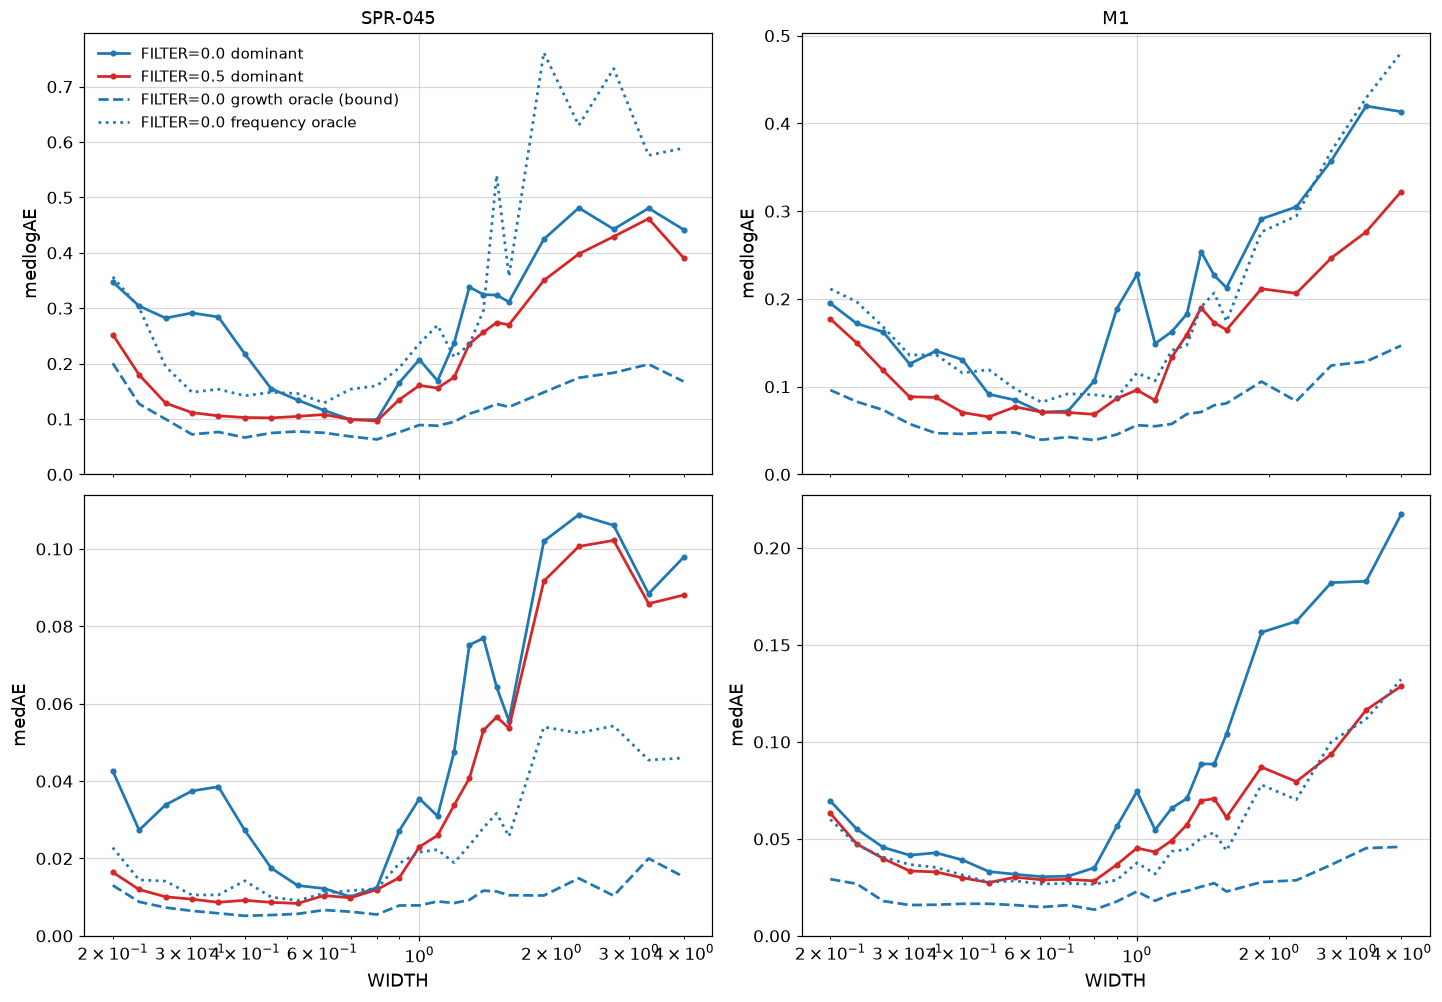

In [17]:
fig5, axes5 = plt.subplots(2, len(cases), figsize=(13, 9), sharex=True)
for col, db in enumerate(cases):
    s = f05[f05.db == db]
    for row, (m, lab) in enumerate((("medlog", r"medlogAE"), ("medAE", "medAE"))):
        ax = axes5[row, col]
        ax.plot(s.width, s[f"{m}_f00"], color="C0", marker="o", ms=3, label="FILTER=0.0 dominant")
        ax.plot(s.width, s[f"{m}_f05"], color="C3", marker="o", ms=3, label="FILTER=0.5 dominant")
        ax.plot(s.width, s[f"{m}_orc"], color="C0", ls="--", marker="", label="FILTER=0.0 growth oracle (bound)")
        ax.plot(s.width, s[f"{m}_orcw"], color="C0", ls=":", marker="", label="FILTER=0.0 frequency oracle")
        ax.set(xscale="log", ylabel=lab, ylim=(0, None))
    axes5[0, col].set(title=f"{db}")
    axes5[1, col].set(xlabel="WIDTH")
axes5[0, 0].legend()
plt.show()

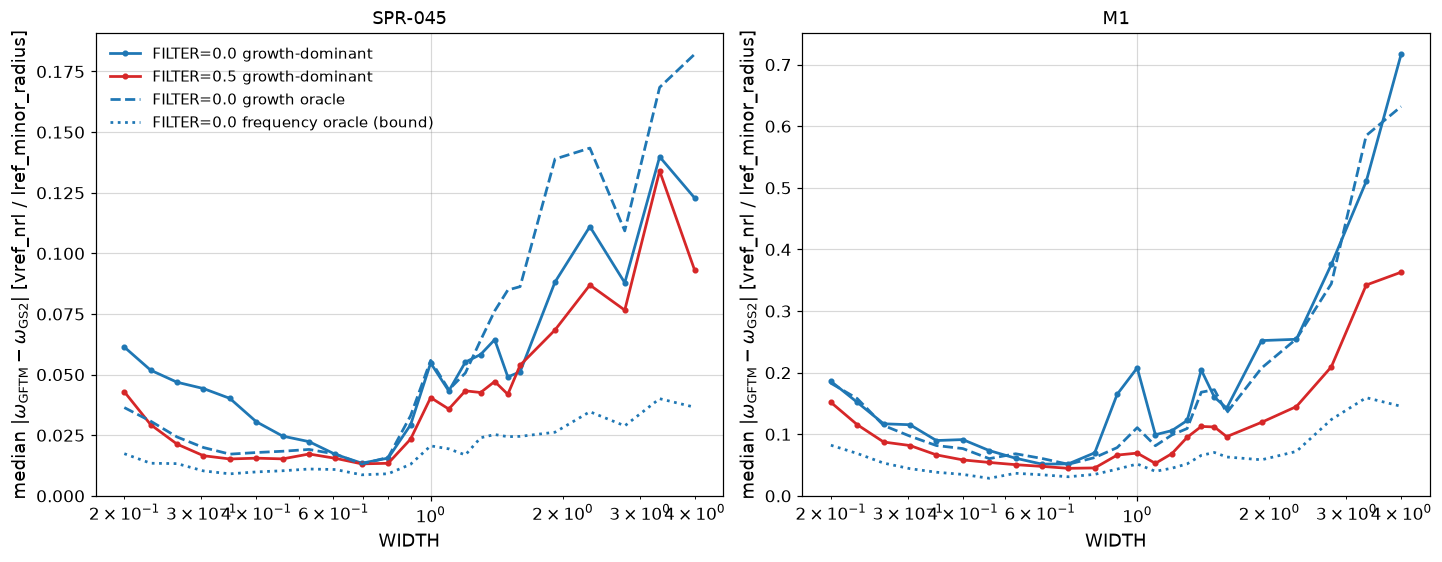

In [18]:
frequency_units = str(gftm05[next(iter(cases)), widths[0]].data.mode_frequency.data.units)
fig6, axes6 = plt.subplots(1, len(cases), figsize=(13, 5), sharex=True, squeeze=False)
for col, db in enumerate(cases):
    s = f05[f05.db == db]
    ax = axes6[0, col]
    ax.plot(s.width, s.medAE_freq_f00, color="C0", marker="o", ms=3, label="FILTER=0.0 growth-dominant")
    ax.plot(s.width, s.medAE_freq_f05, color="C3", marker="o", ms=3, label="FILTER=0.5 growth-dominant")
    ax.plot(s.width, s.medAE_freq_orcg, color="C0", ls="--", marker="", label="FILTER=0.0 growth oracle")
    ax.plot(s.width, s.medAE_freq_orc, color="C0", ls=":", marker="", label="FILTER=0.0 frequency oracle (bound)")
    ax.set(xscale="log", xlabel="WIDTH", ylabel=rf"median $|\omega_{{\rm GFTM}}-\omega_{{\rm GS2}}|$ [{frequency_units}]",
           title=db, ylim=(0, None))
axes6[0, 0].legend()
plt.show()

Saved with the other figures below. The verdict (widths where FILTER=0.5 wins, by how much, at what miss cost, fraction of the oracle
gap closed) is written in the Fusion_PhD `results/kbm_extent_filter/README.md` from this executed output.

In [19]:
fig5.savefig(ROOT / "Plots" / analysis_name / "fig5_filter05_medlog_vs_width.png")

# How does the extent cutoff change the frequency prediction?

The cutoff sweep above scores only growth rates. Here the same selectors (FILTER=0.0 cubes; absolute and relative
cutoffs on the phi and apar extents; same GS2-unstable population) are scored on the **frequency of the selected mode**:
median |omega_GFTM - omega_GS2|. A MISS predicts omega = 0, so its error is |omega_GS2|, consistent with the FILTER=0.5
section. c = 0 is the growth-dominant mode, checked against `medAE_freq_f00`. The reference bound is the frequency
oracle (unstable mode closest to GS2 in frequency). Also reported: the frequency change at the cutoff that minimises
growth-rate medlog, i.e. what tuning the cutoff for gamma does to omega.

## Extent cutoff and frequency: calculate

In [20]:
freq_sweep = []
for (db, w), v in cases_data.items():
    d, ref = gftm[db, w].data, gs2[db].data
    assert str(d.mode_frequency.data.units) == str(ref.mode_frequency.data.units), "frequency normalisations differ"
    in_population = np.isin(d.sample_name.values, v["names"])     # same cases, same order as cases_data
    freq = mag(d.mode_frequency.transpose("sample", "mode"))[in_population]
    freq_ref_by_name = dict(zip(ref.sample_name.values, mag(ref.mode_frequency)))
    freq_ref = np.array([freq_ref_by_name[n] for n in v["names"]])
    gam, ext, r = v["gam"], v["ext"], np.arange(len(v["gam"]))
    assert np.isfinite(freq_ref).all() and np.isfinite(freq[gam > 0]).all(), f"{db}/{w}: non-finite frequency"

    longest = np.nanmax(np.where(gam > 0, ext["phi"], np.nan), axis=1, initial=0)   # as in the growth-rate sweep
    for f in fields:
        for kind, grid in (("abs", cutoffs), ("rel", rel_cutoffs)):
            for c in grid:
                threshold = c if kind == "abs" else c * longest[:, None]
                keep = (ext[f] >= threshold) | (c == 0)
                g_sel, i_sel = select(gam, keep)
                freq_sel = np.where(g_sel > 0, freq[r, i_sel], 0.0)   # a MISS predicts omega = 0
                freq_sweep.append(dict(db=db, width=width_value[w], field=f, kind=kind, cutoff=c,
                                       medAE_freq=np.median(np.abs(freq_sel - freq_ref)),
                                       miss=int((g_sel == 0).sum()), n=len(freq_ref)))
freq_sweep = pd.DataFrame(freq_sweep)


In [21]:
keys = ["db", "field", "kind", "width"]
base_freq = freq_sweep[freq_sweep.cutoff == 0].set_index(keys)
c0 = base_freq.xs(("phi", "abs"), level=("field", "kind")).medAE_freq
assert np.allclose(c0, f05.set_index(["db", "width"]).medAE_freq_f00.reindex(c0.index)), "c = 0 is not the growth-dominant mode"

best_freq = freq_sweep.sort_values("medAE_freq").groupby(keys).head(1).set_index(keys).sort_index()
best_freq = best_freq.assign(medAE_freq_c0=base_freq.medAE_freq, rel_change=best_freq.medAE_freq / base_freq.medAE_freq - 1)
at_gamma_cutoff = best.reset_index()[keys + ["cutoff"]].merge(freq_sweep, on=keys + ["cutoff"]).set_index(keys)
best_freq = best_freq.assign(cutoff_gamma=at_gamma_cutoff.cutoff,
                             rel_change_at_cutoff_gamma=at_gamma_cutoff.medAE_freq / base_freq.medAE_freq - 1)
best_freq = best_freq.join(f05.set_index(["db", "width"])[["medAE_freq_orc"]])
for f in fields:
    for kind in ("abs", "rel"):
        print(f"--- {f}, {kind} cutoff ---")
        print(best_freq.loc[(slice(None), f, kind), ["cutoff", "medAE_freq", "medAE_freq_c0", "rel_change", "miss",
                                                     "cutoff_gamma", "rel_change_at_cutoff_gamma", "medAE_freq_orc"]]
              .round(4).to_string())
for f in fields:
    for kind in ("abs", "rel"):
        b = best_freq.loc[(slice(None), f, kind)]
        print(f"{f}/{kind}: widths where some cutoff lowers freq medAE by >1%: "
              + ", ".join(f"{db} {(b.loc[db].rel_change < -0.01).sum()}/{len(widths)} (best {b.loc[db].rel_change.min():+.1%})" for db in cases)
              + " | at the growth-optimal cutoff: "
              + ", ".join(f"{db} median {b.loc[db].rel_change_at_cutoff_gamma.median():+.1%}, worst {b.loc[db].rel_change_at_cutoff_gamma.max():+.1%}" for db in cases))


--- phi, abs cutoff ---
                           cutoff  medAE_freq  medAE_freq_c0  rel_change  miss  cutoff_gamma  rel_change_at_cutoff_gamma  medAE_freq_orc
db      field kind width                                                                                                                
M1      phi   abs  0.2000    0.00      0.1859         0.1859      0.0000     0          1.50                      0.0407          0.0821
                   0.2297    0.00      0.1518         0.1518      0.0000     0          0.50                      0.0000          0.0688
                   0.2639    0.75      0.1151         0.1169     -0.0160     0          1.50                      0.0747          0.0531
                   0.3031    0.00      0.1154         0.1154      0.0000     0          1.50                      0.0285          0.0441
                   0.3482    0.25      0.0898         0.0898      0.0000     0          1.50                      0.0000          0.0383
                 

## Extent cutoff and frequency: plot

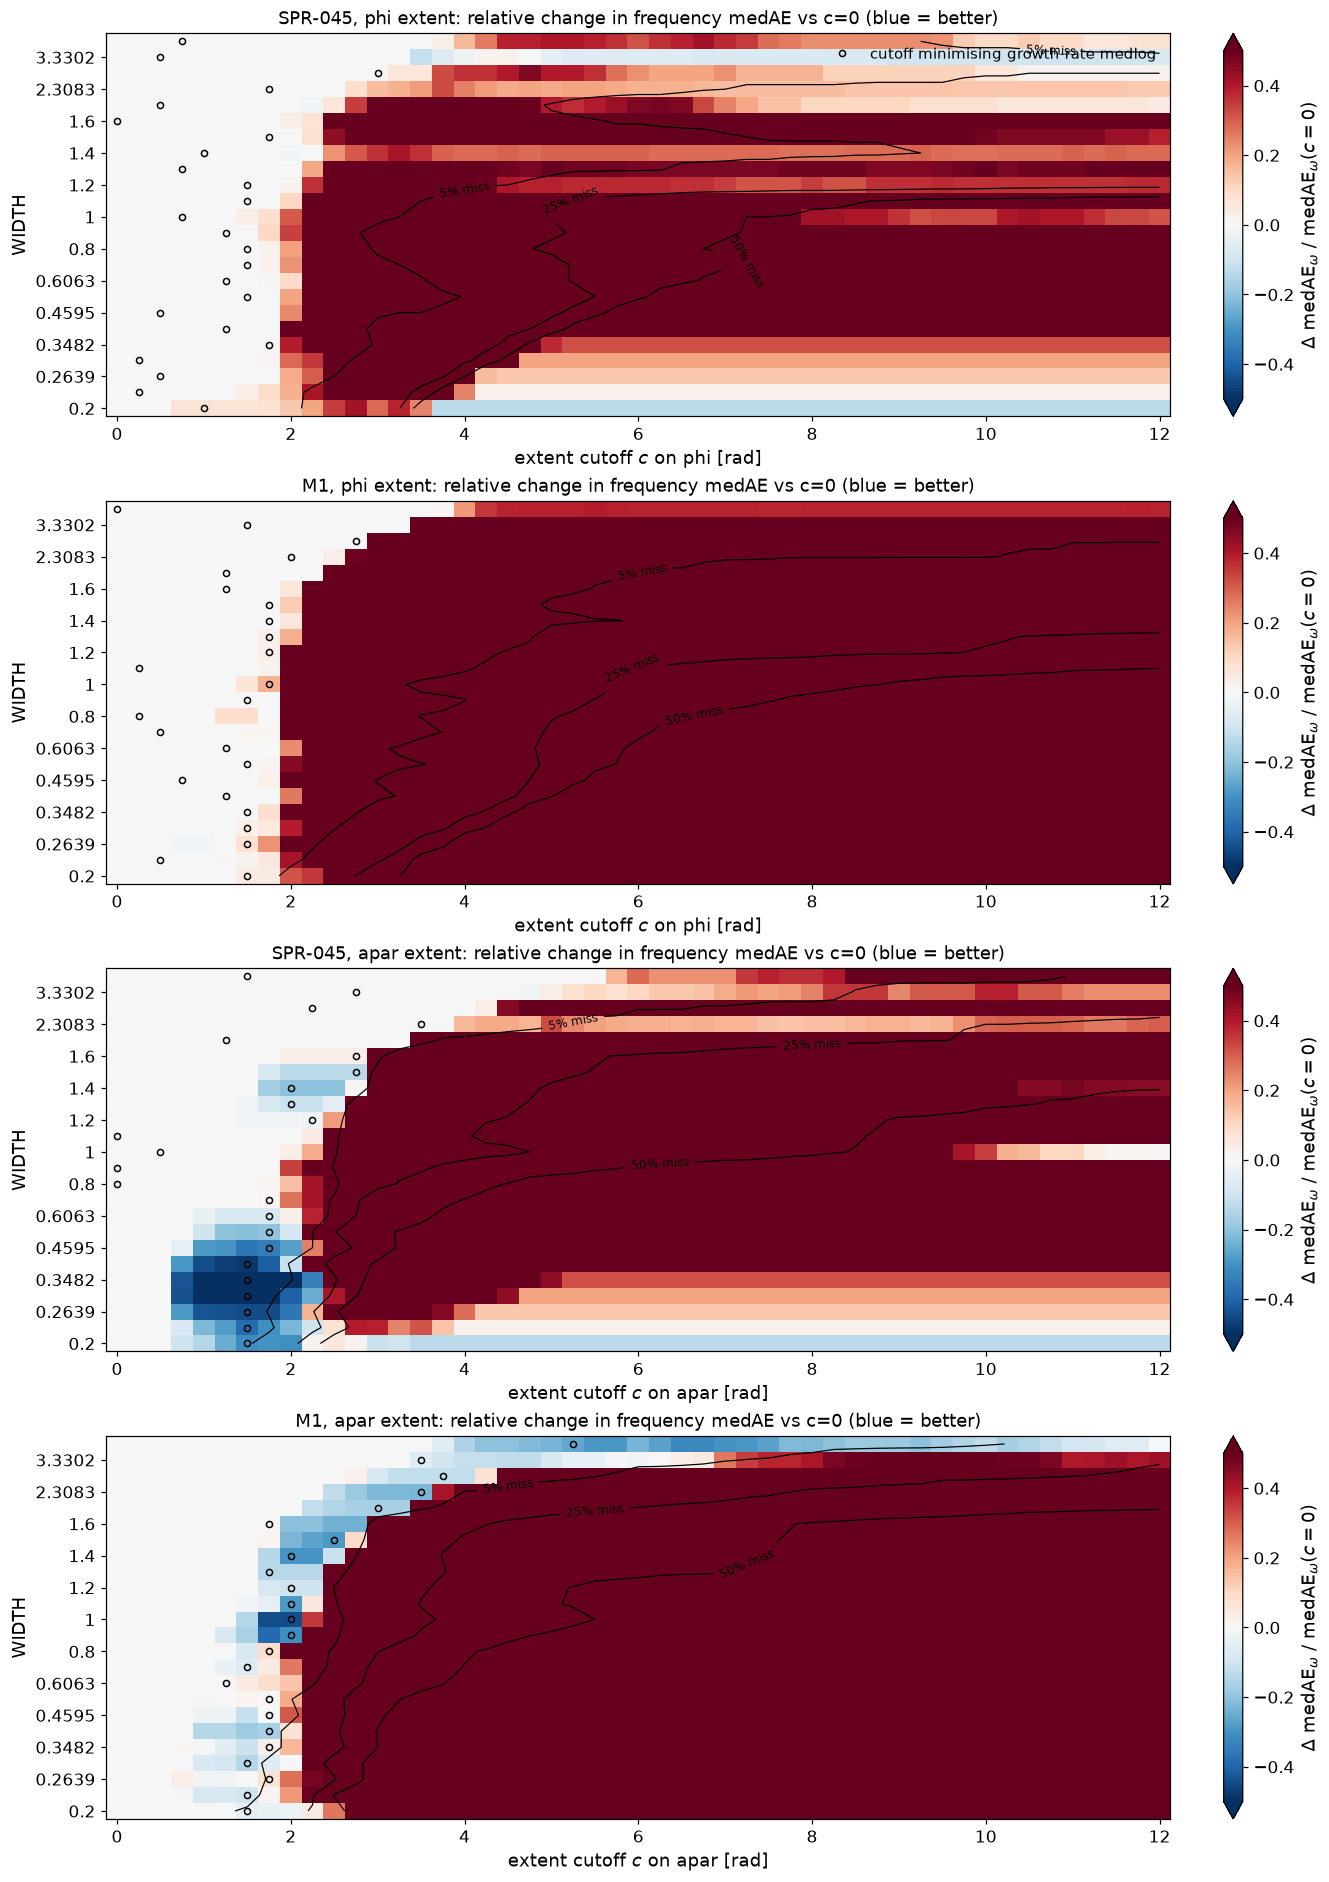

In [22]:
freq_rel_lim = 0.5   # fig 7 colour range for the relative change in frequency medAE (clipped)
fig7, axes7 = plt.subplots(2 * len(fields), 1, figsize=(12, 17))
for row, (f, db) in enumerate([(f, db) for f in fields for db in cases]):
    s = freq_sweep[(freq_sweep.db == db) & (freq_sweep.field == f) & (freq_sweep.kind == "abs")]
    grid = s.pivot(index="width", columns="cutoff", values="medAE_freq")
    rel = grid.div(grid[0.0], axis=0) - 1
    miss = s.pivot(index="width", columns="cutoff", values="miss") / s.n.iloc[0]
    y = np.arange(len(widths))
    m = axes7[row].pcolormesh(cutoffs, y, rel.values, cmap="RdBu_r", norm=TwoSlopeNorm(0, -freq_rel_lim, freq_rel_lim), shading="nearest")
    cs = axes7[row].contour(cutoffs, y, miss.values, levels=[0.05, 0.25, 0.5], colors="k", linewidths=0.8)
    axes7[row].clabel(cs, fmt=lambda v: f"{v:.0%} miss", fontsize=8)
    axes7[row].plot(best.loc[(db, f, "abs")].cutoff.values, y, "o", color="k", mfc="none", ms=4,
                    label="cutoff minimising growth-rate medlog")
    axes7[row].set(xlabel=f"extent cutoff $c$ on {f} [rad]", ylabel="WIDTH", yticks=y[::2],
                   yticklabels=[f"{v:g}" for v in grid.index[::2]],
                   title=f"{db}, {f} extent: relative change in frequency medAE vs c=0 (blue = better)")
    axes7[row].grid(False)
    fig7.colorbar(m, ax=axes7[row], label=r"$\Delta$ medAE$_\omega$ / medAE$_\omega(c=0)$", extend="both")
axes7[0].legend(loc="upper right")
plt.show()


In [23]:
fig7.savefig(ROOT / "Plots" / analysis_name / "fig7_freq_heatmap_width_cutoff.png")


# One fixed extent filter for frequency

The table above tunes the cutoff separately at every width, on the same cases it scores: an optimistic, unusable
filter. Here each (field, cutoff type) gets **one cutoff for all widths**, chosen per database to minimise the mean
(over widths) relative change in frequency medAE vs c = 0, among cutoffs that miss at most `max_miss_frac` of cases at
**every** width. The mean, not the median: gains appear at a minority of widths, so the median change is exactly 0 for
every admissible cutoff. Then the choice made on one database is scored on the other (SPR-045 -> M1, M1 -> SPR-045),
the honest test that the cutoff is not fitted to one case set. The frequency oracle remains a bound.

## Fixed extent filter: calculate

In [24]:
max_miss_frac = 0.05   # a fixed filter may miss at most this fraction of cases at any width
improved_threshold = -0.01   # a width counts as improved when freq medAE drops by more than 1%

fs = freq_sweep.merge(base_freq.medAE_freq.rename("medAE_freq_c0").reset_index(), on=keys)
fs = fs.assign(rel_change=fs.medAE_freq / fs.medAE_freq_c0 - 1, miss_frac=fs.miss / fs.n)
fixed = (fs.groupby(["db", "field", "kind", "cutoff"])
         .agg(mean_rel_change=("rel_change", "mean"), median_rel_change=("rel_change", "median"),
              best_rel_change=("rel_change", "min"), worst_rel_change=("rel_change", "max"),
              widths_improved=("rel_change", lambda x: int((x < improved_threshold).sum())),
              max_miss_frac=("miss_frac", "max"))
         .reset_index())
# mean, not median, over widths: gains at a minority of widths leave the median at exactly 0; ties -> smaller cutoff
chosen = (fixed[fixed.max_miss_frac <= max_miss_frac].sort_values(["mean_rel_change", "cutoff"])
          .groupby(["db", "field", "kind"]).head(1).set_index(["db", "field", "kind"]).sort_index())

other = dict(zip(cases, list(cases)[::-1]))
fixed_by_cutoff = fixed.set_index(["db", "field", "kind", "cutoff"])
transfer = pd.DataFrame([dict(chosen_on=db, tested_on=other[db], field=f, kind=k, cutoff=row.cutoff,
                              **fixed_by_cutoff.loc[(other[db], f, k, row.cutoff)].to_dict())
                         for (db, f, k), row in chosen.iterrows()])

# growth-rate side effect of the same fixed cutoffs: change in medlog vs c = 0, from the growth-rate sweep
growth = sweep.merge(sweep[sweep.cutoff == 0][keys + ["medlog"]].rename(columns={"medlog": "medlog_c0"}), on=keys)
growth = growth.assign(d_medlog=growth.medlog - growth.medlog_c0)
growth_fixed = growth.groupby(["db", "field", "kind", "cutoff"]).d_medlog.agg(
    mean_d_medlog="mean", best_d_medlog="min", worst_d_medlog="max")
transfer = transfer.join(growth_fixed, on=["tested_on", "field", "kind", "cutoff"])

print(f"--- cutoff chosen and scored on the same database (max miss {max_miss_frac:.0%} at every width) ---")
print(chosen.round(4).to_string())
print("--- cutoff chosen on one database, scored on the other (frequency, then growth-rate medlog) ---")
print(transfer.round(4).to_string(index=False))

--- cutoff chosen and scored on the same database (max miss 5% at every width) ---
                    cutoff  mean_rel_change  median_rel_change  best_rel_change  worst_rel_change  widths_improved  max_miss_frac
db      field kind                                                                                                               
M1      apar  abs     1.25          -0.0222                0.0          -0.1441            0.0000                8         0.0397
              rel     0.10          -0.0304                0.0          -0.1415            0.0000               10         0.0000
        phi   abs     0.75          -0.0007                0.0          -0.0160            0.0000                1         0.0000
              rel     0.00           0.0000                0.0           0.0000            0.0000                0         0.0000
SPR-045 apar  abs     1.50          -0.1467                0.0          -0.6217            0.0000               11         0.0409
       

## Fixed extent filter: plot

Top: frequency medAE vs WIDTH. Bottom: growth-rate medlog vs WIDTH for the **same** selected modes, i.e. what the
frequency-chosen filter does to gamma. Each fixed filter uses the cutoff chosen on **the other** database (the
transferred choice); c = 0 is the growth-dominant mode; dotted/dashed are the frequency/growth oracle bounds.

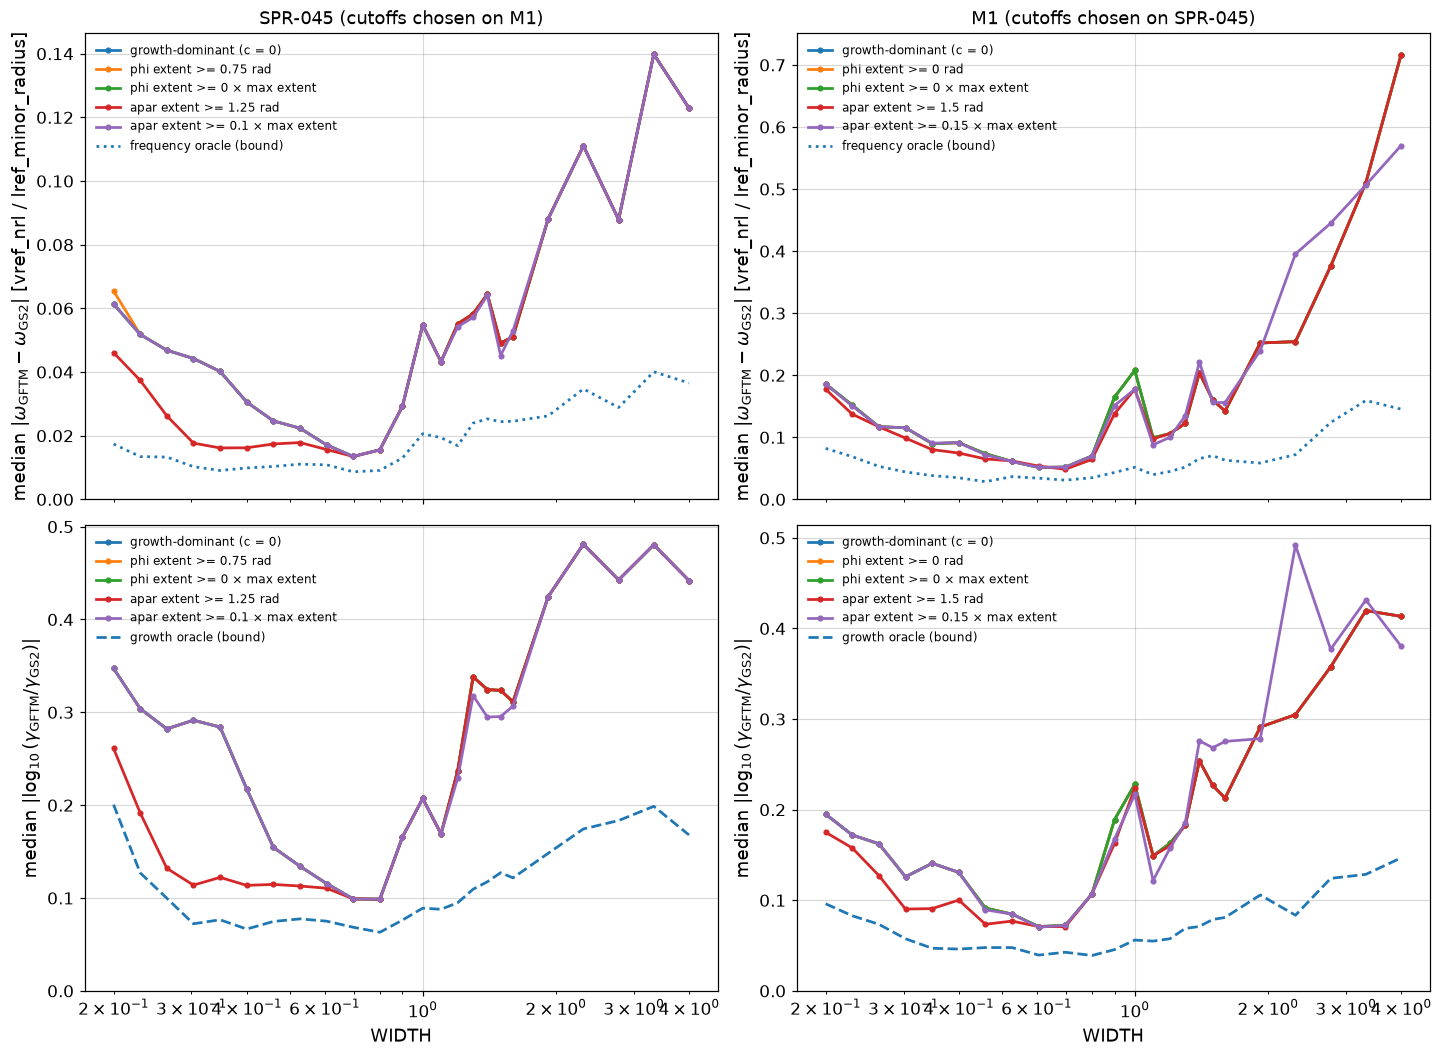

In [25]:
fig8, axes8 = plt.subplots(2, len(cases), figsize=(13, 9.5), sharex=True, squeeze=False)
for col, db in enumerate(cases):
    s0 = fs[(fs.db == db) & (fs.field == "phi") & (fs.kind == "abs") & (fs.cutoff == 0)]
    g0 = sweep[(sweep.db == db) & (sweep.field == "phi") & (sweep.kind == "abs") & (sweep.cutoff == 0)]
    axes8[0, col].plot(s0.width, s0.medAE_freq, color="C0", marker="o", ms=3, label="growth-dominant (c = 0)")
    axes8[1, col].plot(g0.width, g0.medlog, color="C0", marker="o", ms=3, label="growth-dominant (c = 0)")
    for i, (f, k) in enumerate([(f, k) for f in fields for k in ("abs", "rel")]):
        c = chosen.loc[(other[db], f, k)].cutoff
        s = fs[(fs.db == db) & (fs.field == f) & (fs.kind == k) & (fs.cutoff == c)]
        g = sweep[(sweep.db == db) & (sweep.field == f) & (sweep.kind == k) & (sweep.cutoff == c)]
        unit = " rad" if k == "abs" else r" $\times$ max extent"
        axes8[0, col].plot(s.width, s.medAE_freq, color=f"C{i + 1}", marker="o", ms=3, label=f"{f} extent >= {c:g}{unit}")
        axes8[1, col].plot(g.width, g.medlog, color=f"C{i + 1}", marker="o", ms=3, label=f"{f} extent >= {c:g}{unit}")
    s = f05[f05.db == db]
    axes8[0, col].plot(s.width, s.medAE_freq_orc, color="C0", ls=":", marker="", label="frequency oracle (bound)")
    axes8[1, col].plot(s.width, s.medlog_orc, color="C0", ls="--", marker="", label="growth oracle (bound)")
    axes8[0, col].set(xscale="log", ylabel=rf"median $|\omega_{{\rm GFTM}}-\omega_{{\rm GS2}}|$ [{frequency_units}]",
                      title=f"{db} (cutoffs chosen on {other[db]})", ylim=(0, None))
    axes8[1, col].set(xscale="log", xlabel="WIDTH", ylabel=r"median $|\log_{10}(\gamma_{\rm GFTM}/\gamma_{\rm GS2})|$",
                      ylim=(0, None))
    axes8[0, col].legend(fontsize=8)
    axes8[1, col].legend(fontsize=8)
plt.show()

In [26]:
fig8.savefig(ROOT / "Plots" / analysis_name / "fig8_fixed_extent_filter_frequency.png")

## Fixed extent filter: interpretation

- **phi extent: no usable filter.** No fixed phi cutoff within the miss budget lowers frequency medAE at more than one width.
- **apar extent, absolute cutoff ~1.25-1.5 rad: the one that transfers.** Chosen on M1 (1.25 rad) and applied to
  SPR-045: mean -13% frequency medAE, down to -60% at the smallest widths (0.2-0.5), never worse at any width,
  <1% misses. Chosen on SPR-045 (1.5 rad) and applied to M1: a modest mean -5%, gains at 11/24 widths, worst +4%,
  but it exceeds the 5% miss budget (6.4%) at one width.
- **Growth rate moves with frequency, not against it.** The same apar absolute cutoffs lower growth-rate medlog too and
  never raise it at any width: SPR-045 mean -0.036 (best -0.18, at WIDTH 0.2-0.5, down to near the growth oracle),
  M1 mean -0.010 (best -0.05). The filter removes modes that are wrong in both gamma and omega.
- **apar relative cutoff does not transfer**: 0.15 x max extent (chosen on SPR-045) makes M1 worse by up to +56% in
  frequency and +0.19 in growth medlog at large WIDTH.
- Even the best fixed filter leaves most of the gap to the frequency oracle, and it helps mainly at small WIDTH, where
  GFTM's FILTER=0.5 parity gate (fig 6) already gives comparable gains. Whether the two combine is not tested here.
- The apar extent is phase-sensitive (check 2: 23-58% of unstable modes move >10% under a phase rotation), so the
  cutoff value is tied to pyro's current |Re(apar)| convention.

# Extent filter vs FILTER=0.5, and an extent filter on top of FILTER=0.5

(A) Is the fixed apar extent cutoff on the FILTER=0.0 cubes (above) better or worse than GFTM's own parity filter
(FILTER=0.5, no extent cut)? Scored per width on the same GS2-unstable cases.

(B) Does an extent cutoff applied **on top of** FILTER=0.5 improve its growth-rate or frequency prediction further?
The same sweep (phi/apar, absolute/relative cutoffs) is run on the FILTER=0.5 cubes. A fixed cutoff per
(field, cutoff type) is chosen as above, within the `max_miss_frac` miss budget at every width, in two ways: to
minimise the mean relative change in frequency medAE, or the mean change in growth-rate medlog, versus FILTER=0.5
alone. Each choice is scored on **the other database**. For consistency, the FILTER=0.0 frequency choices are
recomputed the same way and checked against `chosen`.

## Extent on top of FILTER=0.5: calculate

In [27]:
sweep05 = []
for (db, w), v in cases_data.items():
    d5, ref = gftm05[db, w].data, gs2[db].data
    in_population = np.isin(d5.sample_name.values, v["names"])
    assert (d5.sample_name.values[in_population] == v["names"]).all(), f"{db}/{w}: population differs from FILTER=0.0"
    gam = mag(d5.growth_rate.transpose("sample", "mode"))[in_population]
    freq = mag(d5.mode_frequency.transpose("sample", "mode"))[in_population]
    ext = {f: mag(d5.extent.sel(field=f).transpose("sample", "mode"))[in_population] for f in fields}
    freq_ref_by_name = dict(zip(ref.sample_name.values, mag(ref.mode_frequency)))
    freq_ref = np.array([freq_ref_by_name[n] for n in v["names"]])
    g_ref, r = v["g_ref"], np.arange(len(v["g_ref"]))

    longest = np.nanmax(np.where(gam > 0, ext["phi"], np.nan), axis=1, initial=0)   # as in the FILTER=0.0 sweeps
    for f in fields:
        for kind, grid in (("abs", cutoffs), ("rel", rel_cutoffs)):
            for c in grid:
                threshold = c if kind == "abs" else c * longest[:, None]
                keep = (ext[f] >= threshold) | (c == 0)
                g_sel, i_sel = select(gam, keep)
                freq_sel = np.where(g_sel > 0, freq[r, i_sel], 0.0)   # a MISS predicts omega = 0
                medAE, medlog, miss = score(g_sel, g_ref)
                sweep05.append(dict(db=db, width=width_value[w], field=f, kind=kind, cutoff=c, medlog=medlog, medAE=medAE,
                                    medAE_freq=np.median(np.abs(freq_sel - freq_ref)), miss=miss, n=len(g_ref)))
sweep05 = pd.DataFrame(sweep05)

# one long table for both arms; changes are measured against each arm's own c = 0
arm_keys = ["arm"] + keys
both = pd.concat([sweep.merge(freq_sweep[keys + ["cutoff", "medAE_freq"]], on=keys + ["cutoff"]).assign(arm="FILTER=0.0"),
                  sweep05.assign(arm="FILTER=0.5")], ignore_index=True)
both = both.merge(both[both.cutoff == 0][arm_keys + ["medlog", "medAE_freq"]]
                  .rename(columns={"medlog": "medlog_c0", "medAE_freq": "medAE_freq_c0"}), on=arm_keys)
both = both.assign(freq_rel_change=both.medAE_freq / both.medAE_freq_c0 - 1, d_medlog=both.medlog - both.medlog_c0,
                   miss_frac=both.miss / both.n)

c0_05 = both[(both.arm == "FILTER=0.5") & (both.cutoff == 0) & (both.field == "phi") & (both.kind == "abs")].set_index(["db", "width"])
ref05 = f05.set_index(["db", "width"]).reindex(c0_05.index)
assert np.allclose(c0_05.medlog, ref05.medlog_f05) and np.allclose(c0_05.medAE_freq, ref05.medAE_freq_f05), "c = 0 is not FILTER=0.5 dominant"

per_cutoff = (both.groupby(["arm", "db", "field", "kind", "cutoff"])
              .agg(mean_freq_rel_change=("freq_rel_change", "mean"), worst_freq_rel_change=("freq_rel_change", "max"),
                   mean_d_medlog=("d_medlog", "mean"), worst_d_medlog=("d_medlog", "max"),
                   mean_medAE_freq=("medAE_freq", "mean"), mean_medlog=("medlog", "mean"), max_miss_frac=("miss_frac", "max"))
              .reset_index())
admissible = per_cutoff[per_cutoff.max_miss_frac <= max_miss_frac]
picked = pd.concat([admissible.sort_values([col, "cutoff"]).groupby(["arm", "db", "field", "kind"]).head(1).assign(objective=obj)
                    for obj, col in (("frequency", "mean_freq_rel_change"), ("growth", "mean_d_medlog"))])
check = picked[(picked.arm == "FILTER=0.0") & (picked.objective == "frequency")].set_index(["db", "field", "kind"]).cutoff
assert np.allclose(check, chosen.cutoff.reindex(check.index)), "FILTER=0.0 frequency choices differ from `chosen`"

# score each choice on the other database
scored = pd.DataFrame(dict(arm=picked.arm, objective=picked.objective, chosen_on=picked.db, db=picked.db.map(other),
                           field=picked.field, kind=picked.kind, cutoff=picked.cutoff))
scored = scored.merge(per_cutoff, on=["arm", "db", "field", "kind", "cutoff"]).rename(columns={"db": "tested_on"})

In [28]:
print("--- (A) FILTER=0.0 + fixed apar extent cutoff (chosen on the other database) vs FILTER=0.5 alone ---")
rows_a = []
for db in cases:
    c_ext = chosen.loc[(other[db], "apar", "abs")].cutoff
    ext00 = both[(both.arm == "FILTER=0.0") & (both.db == db) & (both.field == "apar") & (both.kind == "abs")
                 & (both.cutoff == c_ext)].set_index("width")
    s = f05[f05.db == db].set_index("width")
    rows_a.append(dict(db=db, apar_cutoff=c_ext,
                       mean_freq_f00=s.medAE_freq_f00.mean(), mean_freq_f00_ext=ext00.medAE_freq.mean(), mean_freq_f05=s.medAE_freq_f05.mean(),
                       widths_freq_ext_beats_f05=int((ext00.medAE_freq < s.medAE_freq_f05).sum()),
                       mean_medlog_f00=s.medlog_f00.mean(), mean_medlog_f00_ext=ext00.medlog.mean(), mean_medlog_f05=s.medlog_f05.mean(),
                       widths_medlog_ext_beats_f05=int((ext00.medlog < s.medlog_f05).sum()), n_widths=len(s)))
print(pd.DataFrame(rows_a).round(4).to_string(index=False))

print("\n--- (B) extent cutoff on top of FILTER=0.5, chosen and scored on the same database (optimistic) ---")
print(picked[picked.arm == "FILTER=0.5"].drop(columns="arm").sort_values(["objective", "db", "field", "kind"])
      .round(4).to_string(index=False))

print("\n--- (B) extent cutoff on top of FILTER=0.5, chosen on one database, scored on the other ---")
print("    changes are vs FILTER=0.5 alone; mean_* are means over widths")
print(scored[scored.arm == "FILTER=0.5"].drop(columns="arm").sort_values(["objective", "tested_on", "field", "kind"])
      .round(4).to_string(index=False))

--- (A) FILTER=0.0 + fixed apar extent cutoff (chosen on the other database) vs FILTER=0.5 alone ---
     db  apar_cutoff  mean_freq_f00  mean_freq_f00_ext  mean_freq_f05  widths_freq_ext_beats_f05  mean_medlog_f00  mean_medlog_f00_ext  mean_medlog_f05  widths_medlog_ext_beats_f05  n_widths
SPR-045         1.25         0.0551             0.0498         0.0418                          1           0.2781               0.2424           0.2118                            0        24
     M1         1.50         0.1822             0.1764         0.1106                          0           0.1977               0.1874           0.1414                            1        24

--- (B) extent cutoff on top of FILTER=0.5, chosen and scored on the same database (optimistic) ---
     db field kind  cutoff  mean_freq_rel_change  worst_freq_rel_change  mean_d_medlog  worst_d_medlog  mean_medAE_freq  mean_medlog  max_miss_frac objective
     M1  apar  abs    1.25               -0.0053                 0.

## Extent on top of FILTER=0.5: plot

Top: log10 of the frequency medAE; bottom: log10 of the growth-rate medAE, vs WIDTH. FILTER=0.0 and FILTER=0.5 dominant
modes, each with and without an apar absolute extent cutoff (cutoffs chosen on **the same** database they are plotted
for: the frequency choice for FILTER=0.0, the growth (medlog) choice for FILTER=0.5). Grey: oracle bounds (FILTER=0.0).

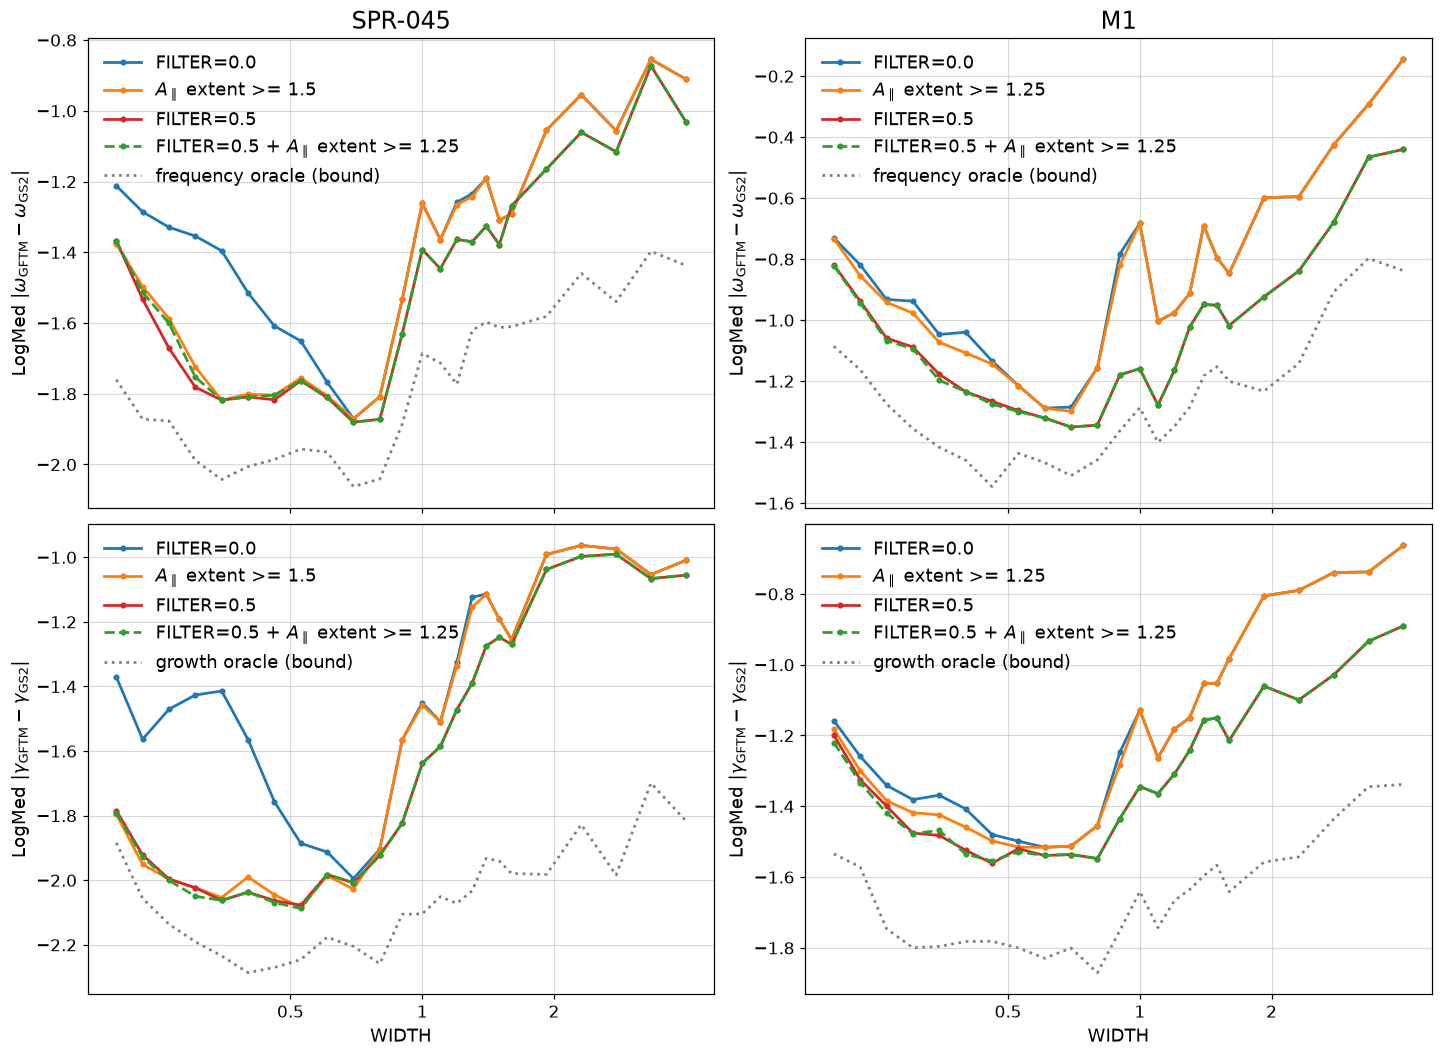

In [96]:
# y = log10 of the median absolute error; log10 is monotonic, so this is the median of log10|error|
# (exact up to how the middle pair is averaged, since n is even)
from matplotlib.ticker import StrMethodFormatter

fig9, axes9 = plt.subplots(2, len(cases), figsize=(13, 9.5), sharex=True, squeeze=False)
for col, db in enumerate(cases):
    c00 = chosen.loc[(db, "apar", "abs")].cutoff
    c05 = picked.set_index(["arm", "objective", "db", "field", "kind"]).loc[("FILTER=0.5", "growth", db, "apar", "abs")].cutoff
    for arm, c, colour, ls, label in (("FILTER=0.0", 0.0, "C0", "-", "FILTER=0.0"),
                                      ("FILTER=0.0", c00, "C1", "-", rf"$A_\parallel$ extent >= {c00:g}"),
                                      ("FILTER=0.5", 0.0, "C3", "-", "FILTER=0.5"),
                                      ("FILTER=0.5", c05, "C2", "--", rf"FILTER=0.5 + $A_\parallel$ extent >= {c05:g}")):
        s = both[(both.arm == arm) & (both.db == db) & (both.field == "apar") & (both.kind == "abs") & (both.cutoff == c)]
        axes9[0, col].plot(s.width, np.log10(s.medAE_freq), color=colour, ls=ls, marker="o", ms=3, label=label)
        axes9[1, col].plot(s.width, np.log10(s.medAE), color=colour, ls=ls, marker="o", ms=3, label=label)
    s = f05[f05.db == db]
    axes9[0, col].plot(s.width, np.log10(s.medAE_freq_orc), color="0.5", ls=":", marker="", label="frequency oracle (bound)")
    axes9[1, col].plot(s.width, np.log10(s.medAE_orc), color="0.5", ls=":", marker="", label="growth oracle (bound)")
    axes9[0, col].set(xscale="log", ylabel=r"LogMed $|\omega_{\rm GFTM}-\omega_{\rm GS2}|$")
    axes9[0, col].set_title(f"{db}", fontsize=16)
    axes9[1, col].set(xscale="log", xlabel="WIDTH", ylabel=r"LogMed $|\gamma_{\rm GFTM}-\gamma_{\rm GS2}|$")
    axes9[0, col].legend(fontsize=12)
    axes9[1, col].legend(fontsize=12)

ax = axes9[0, 0]   # sharex: ticks apply to every panel
lims = ax.get_xlim()
ax.set_xticks([0.5, 1, 2, 5, 10])
ax.set_xlim(lims)
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
for a in axes9.flat:
    a.minorticks_off()
plt.show()

In [95]:
fig9.savefig(ROOT / "Plots" / analysis_name / "fig9_extent_vs_and_on_top_of_filter05.png")

## Extent vs and on top of FILTER=0.5: interpretation

- **(A) FILTER=0.5 beats the extent filter.** Against FILTER=0.0 + the transferred apar cutoff, FILTER=0.5 alone has
  lower mean frequency medAE (SPR-045 0.042 vs 0.050; M1 0.111 vs 0.176) and lower mean growth medlog (0.212 vs 0.242;
  0.141 vs 0.187), and wins at 23-24 of 24 widths on each metric. The extent filter matches FILTER=0.5 only at small
  WIDTH (~0.25-0.8); at large WIDTH it does nothing, while FILTER=0.5 still helps.
- **(B) An extent cutoff on top of FILTER=0.5 adds nothing.** Even chosen and scored on the same database, the best
  fixed cutoff changes the mean frequency medAE by at most -0.5% and the growth medlog by at most -0.002; scored on the
  other database, changes are within +-2% (frequency) and +-0.007 (growth), with occasional worse widths (up to +18%).
  The modes the apar extent cutoff removes at small WIDTH are, it appears, the same ones the parity filter already
  discards: the extent information is redundant once FILTER=0.5 is on.
- Conclusion: use FILTER=0.5; no extent-based selection is recommended on these KBM hypercubes. The remaining gap to the
  oracle bounds is not about short-extent spurious modes.

# Width oracle over WIDTH 0.3-0.8

The extent and parity filters appear to remove the same spurious modes, and WIDTH changes which mode wins, so choosing
WIDTH per case may act like a filter. Bound on that: for each case, among the widths in `width_oracle_range`, take the
width whose **selected mode** (growth-dominant, with FILTER=0.0 or FILTER=0.5) is closest to GS2, either in growth rate
(|log10(gamma/gamma_GS2)|) or in frequency (|omega - omega_GS2|). Both metrics are reported for both oracles.
Compared against every fixed width in the range. Same GS2-unstable population; a MISS (no unstable mode) scores as above.

**The width oracle consults GS2: it is a bound on what a per-case width choice could achieve, not an accuracy.**

## Width oracle: calculate

In [31]:
width_oracle_range = (0.3, 0.8)
oracle_widths = [w for w in widths if width_oracle_range[0] <= width_value[w] <= width_oracle_range[1]]
print("widths in the oracle range:", [width_value[w] for w in oracle_widths])

rows_wo, chosen_width = [], {}
for db in cases:
    names, g_ref = cases_data[db, oracle_widths[0]]["names"], cases_data[db, oracle_widths[0]]["g_ref"]
    ref = gs2[db].data
    freq_ref_by_name = dict(zip(ref.sample_name.values, mag(ref.mode_frequency)))
    freq_ref = np.array([freq_ref_by_name[n] for n in names])
    r = np.arange(len(names))
    for arm, cubes in (("FILTER=0.0", gftm), ("FILTER=0.5", gftm05)):
        g_w, f_w = [], []   # selected-mode gamma and omega, shape (case, width)
        for w in oracle_widths:
            d = cubes[db, w].data
            assert (cases_data[db, w]["names"] == names).all(), f"{db}/{w}: population differs between widths"
            in_population = np.isin(d.sample_name.values, names)
            assert (d.sample_name.values[in_population] == names).all()
            gam = mag(d.growth_rate.transpose("sample", "mode"))[in_population]
            freq = mag(d.mode_frequency.transpose("sample", "mode"))[in_population]
            g_sel, i_sel = select(gam, True)
            g_w.append(g_sel)
            f_w.append(np.where(g_sel > 0, freq[r, i_sel], 0.0))   # a MISS predicts omega = 0
        g_w, f_w = np.stack(g_w, axis=1), np.stack(f_w, axis=1)
        with np.errstate(divide="ignore"):
            log_err = np.abs(np.log10(g_w / g_ref[:, None]))
        freq_err = np.abs(f_w - freq_ref[:, None])

        choices = [(f"W={width_value[w]:g}", np.full(len(names), j)) for j, w in enumerate(oracle_widths)]
        choices += [("growth width oracle", log_err.argmin(axis=1)), ("frequency width oracle", freq_err.argmin(axis=1))]
        for choice, iw in choices:
            rows_wo.append(dict(db=db, arm=arm, choice=choice, medlog=np.median(log_err[r, iw]),
                                medAE_freq=np.median(freq_err[r, iw]), miss=int((g_w[r, iw] == 0).sum()), n=len(names)))
            chosen_width[db, arm, choice] = np.array([width_value[oracle_widths[j]] for j in iw])
width_oracle = pd.DataFrame(rows_wo)

# fixed-width rows must reproduce the dominant-mode scores computed earlier
fixed_rows = width_oracle[width_oracle.choice.str.startswith("W=")]
fixed_rows = fixed_rows.set_index([fixed_rows.db, fixed_rows.choice.str[2:].astype(float).rename("width")])
for arm, col_log, col_freq in (("FILTER=0.0", "medlog_f00", "medAE_freq_f00"), ("FILTER=0.5", "medlog_f05", "medAE_freq_f05")):
    a = fixed_rows[fixed_rows.arm == arm]
    b = f05.set_index(["db", "width"]).reindex(a.index)
    assert np.allclose(a.medlog, b[col_log]) and np.allclose(a.medAE_freq, b[col_freq]), f"{arm}: fixed widths disagree with f05"

widths in the oracle range: [0.3031, 0.3482, 0.4, 0.4595, 0.5279, 0.6063, 0.6965, 0.8]


In [32]:
table = width_oracle.pivot_table(index=["db", "choice"], columns="arm", values=["medlog", "medAE_freq", "miss"], sort=False)
print(table.round(4).to_string())

print("\n--- width oracle vs best fixed width in the range (best chosen per metric, in-sample) ---")
for db in cases:
    for arm in ("FILTER=0.0", "FILTER=0.5"):
        s = width_oracle[(width_oracle.db == db) & (width_oracle.arm == arm)].set_index("choice")
        fixed_w = s[s.index.str.startswith("W=")]
        print(f"{db} {arm}: growth medlog best fixed {fixed_w.medlog.min():.4f} ({fixed_w.medlog.idxmin()}) -> "
              f"growth oracle {s.loc['growth width oracle', 'medlog']:.4f} (its freq medAE {s.loc['growth width oracle', 'medAE_freq']:.4f}) | "
              f"freq medAE best fixed {fixed_w.medAE_freq.min():.4f} ({fixed_w.medAE_freq.idxmin()}) -> "
              f"freq oracle {s.loc['frequency width oracle', 'medAE_freq']:.4f} (its medlog {s.loc['frequency width oracle', 'medlog']:.4f})")

print("\n--- where the oracles put WIDTH: fraction of cases at the range ends, and agreement between the two oracles ---")
edges = (width_value[oracle_widths[0]], width_value[oracle_widths[-1]])
for db in cases:
    for arm in ("FILTER=0.0", "FILTER=0.5"):
        wg, wf = chosen_width[db, arm, "growth width oracle"], chosen_width[db, arm, "frequency width oracle"]
        print(f"{db} {arm}: growth oracle at an end {np.isin(wg, edges).mean():.0%}, frequency oracle at an end "
              f"{np.isin(wf, edges).mean():.0%} (uniform over {len(oracle_widths)} widths: {2 / len(oracle_widths):.0%}); "
              f"both oracles pick the same width in {np.mean(wg == wf):.0%} of cases")

print("\n--- mode oracle (FILTER=0.0, any of the 4 modes, one fixed width) over the same range, for scale ---")
print(f05[(f05.width >= width_oracle_range[0]) & (f05.width <= width_oracle_range[1])]
      .groupby("db")[["medlog_orc", "medAE_freq_orc"]].min().round(4).to_string())

                                   medlog            medAE_freq                  miss           
arm                            FILTER=0.0 FILTER=0.5 FILTER=0.0 FILTER=0.5 FILTER=0.0 FILTER=0.5
db      choice                                                                                  
SPR-045 W=0.3031                   0.2914     0.1115     0.0442     0.0165        0.0        0.0
        W=0.3482                   0.2841     0.1057     0.0402     0.0152        0.0        0.0
        W=0.4                      0.2175     0.1027     0.0306     0.0155        0.0        0.0
        W=0.4595                   0.1546     0.1020     0.0246     0.0152        0.0        0.0
        W=0.5279                   0.1342     0.1047     0.0223     0.0172        0.0        0.0
        W=0.6063                   0.1155     0.1081     0.0171     0.0155        0.0        1.0
        W=0.6965                   0.0990     0.0990     0.0135     0.0132        0.0        0.0
        W=0.8                 

## Width oracle: plot

Rows: growth medlog and frequency medAE vs fixed WIDTH (FILTER=0.0 and 0.5), with the width-oracle bounds as horizontal
lines (dashed: growth width oracle; dotted: frequency width oracle); bottom: where the FILTER=0.5 oracles put WIDTH.

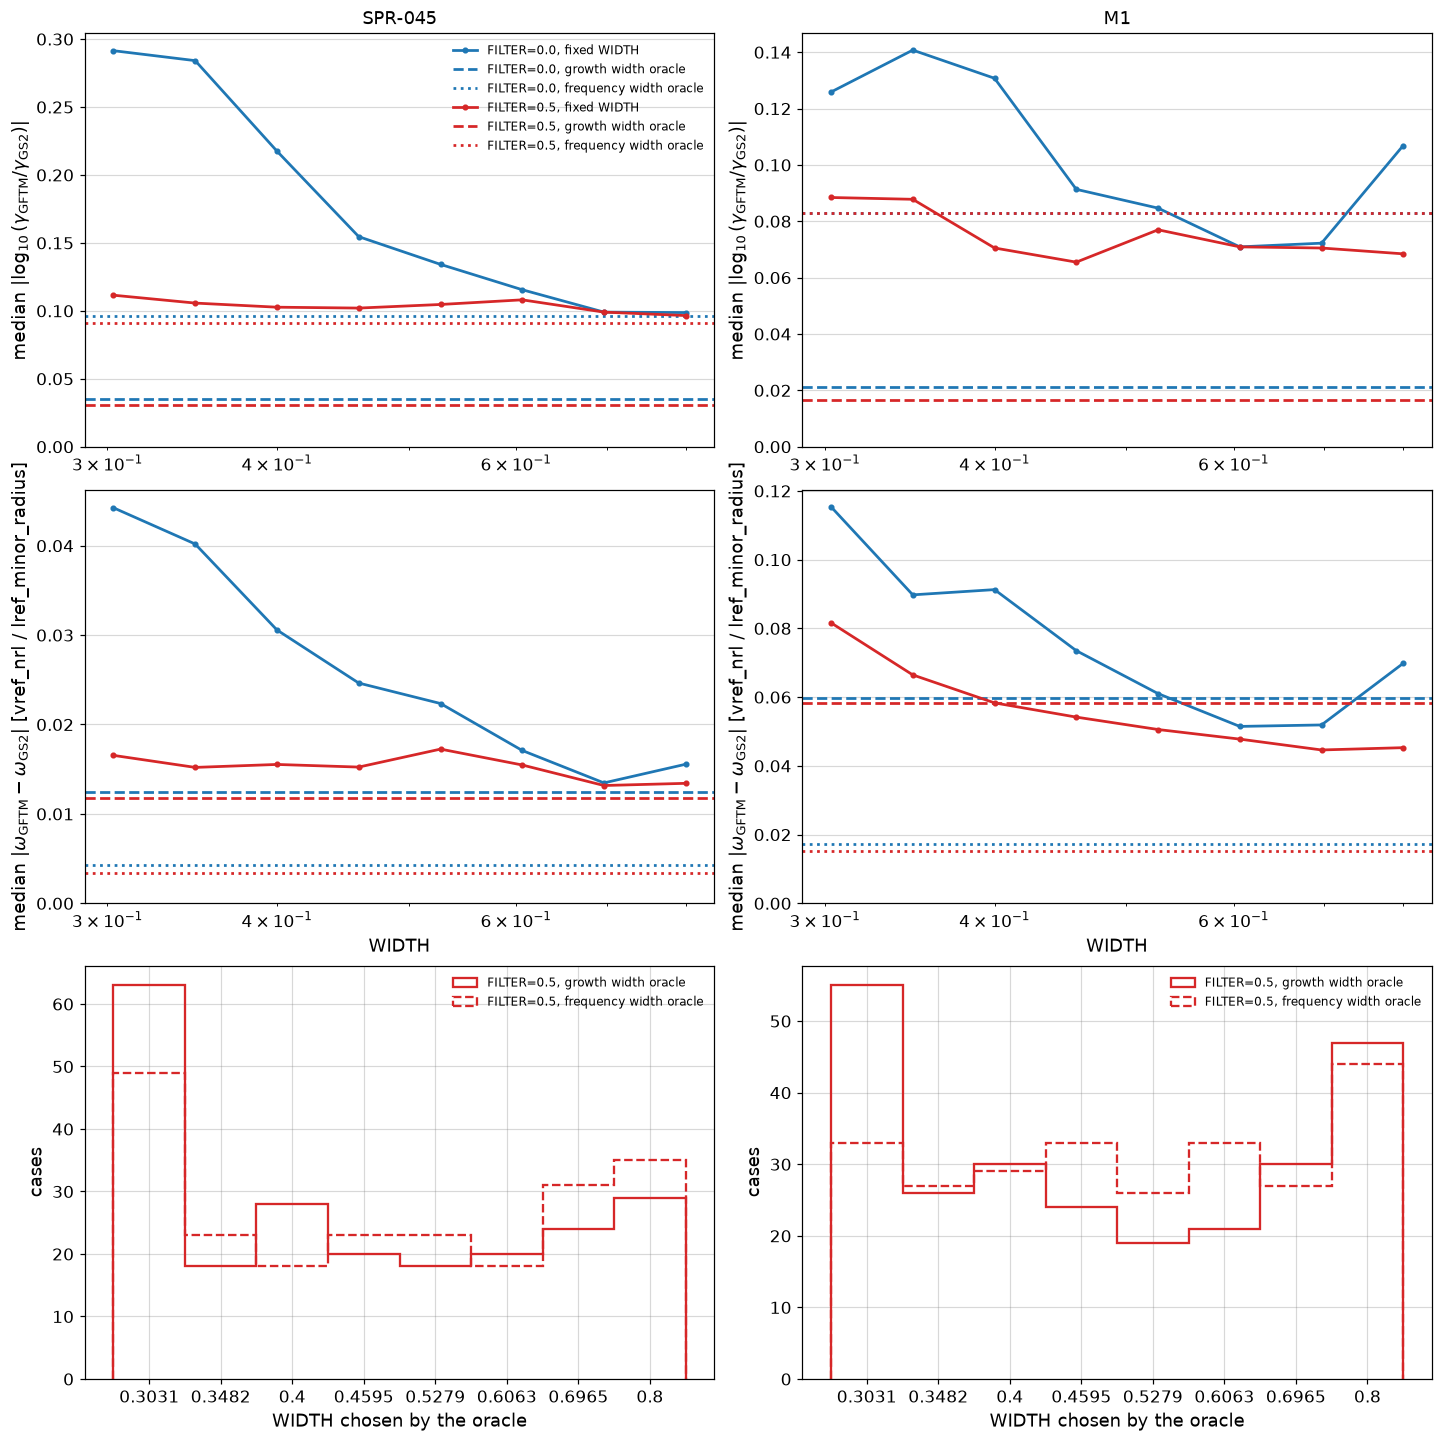

In [33]:
fig10, axes10 = plt.subplots(3, len(cases), figsize=(13, 13), squeeze=False)
for col, db in enumerate(cases):
    for arm, colour in (("FILTER=0.0", "C0"), ("FILTER=0.5", "C3")):
        s = width_oracle[(width_oracle.db == db) & (width_oracle.arm == arm)].set_index("choice")
        fixed_w = s[s.index.str.startswith("W=")]
        w = [width_value[x] for x in oracle_widths]
        for row, m in enumerate(("medlog", "medAE_freq")):
            axes10[row, col].plot(w, fixed_w[m], color=colour, marker="o", ms=3, label=f"{arm}, fixed WIDTH")
            axes10[row, col].axhline(s.loc["growth width oracle", m], color=colour, ls="--", marker="", label=f"{arm}, growth width oracle")
            axes10[row, col].axhline(s.loc["frequency width oracle", m], color=colour, ls=":", marker="", label=f"{arm}, frequency width oracle")
    bins = np.arange(len(oracle_widths) + 1) - 0.5
    for choice, ls in (("growth width oracle", "-"), ("frequency width oracle", "--")):
        idx = np.searchsorted([width_value[x] for x in oracle_widths], chosen_width[db, "FILTER=0.5", choice])
        axes10[2, col].hist(idx, bins=bins, histtype="step", ls=ls, lw=1.5, color="C3", label=f"FILTER=0.5, {choice}")
    axes10[0, col].set(xscale="log", ylabel=r"median $|\log_{10}(\gamma_{\rm GFTM}/\gamma_{\rm GS2})|$", title=db, ylim=(0, None))
    axes10[1, col].set(xscale="log", xlabel="WIDTH", ylabel=rf"median $|\omega_{{\rm GFTM}}-\omega_{{\rm GS2}}|$ [{frequency_units}]", ylim=(0, None))
    axes10[2, col].set(xticks=range(len(oracle_widths)), xticklabels=[f"{width_value[x]:g}" for x in oracle_widths],
                       xlabel="WIDTH chosen by the oracle", ylabel="cases")
    axes10[2, col].legend(fontsize=8)
axes10[0, 0].legend(fontsize=8)
plt.show()

In [34]:
fig10.savefig(ROOT / "Plots" / analysis_name / "fig10_width_oracle.png")

## Width oracle: interpretation

- **The bound is large.** Choosing WIDTH per case in 0.3-0.8 cuts growth medlog ~3x vs the best fixed width
  (SPR-045 0.097 -> 0.030, M1 0.066 -> 0.017, FILTER=0.5) and frequency medAE ~3-4x (0.013 -> 0.003; 0.045 -> 0.015).
  It beats the 4-mode oracle at any single width (0.063 / 0.039 growth; 0.009 / 0.029 frequency). FILTER=0.5 helps
  only slightly under the width oracle (the two filters again overlap).
- **But it acts as a tuning knob, not a filter.** The width that fixes gamma barely helps omega and vice versa: the
  growth width oracle leaves frequency medAE near the best fixed width (SPR-045 0.012 vs 0.013; M1 0.058 vs 0.045,
  worse), the frequency width oracle leaves growth medlog near it (0.091 vs 0.097; 0.083 vs 0.066, worse). The two
  oracles pick the same width in only 17-27% of cases, and pile up at the range ends (35-43% vs 25% uniform).
  A filter that removed wrong modes would improve gamma and omega together; this instead uses WIDTH's continuous
  effect on the eigenvalue to hit one target at a time, and often wants to go beyond the range.
- So a WIDTH predictor (e.g. from local parameters) could only realise this bound for one quantity at a time, and with
  8 candidate widths a min over noisy predictions is itself optimistic. A joint (gamma and omega) oracle, and whether
  the chosen width is predictable from the case parameters, are the next checks.

# GFTM dominant-mode extent vs GS2 extent

For every GS2-unstable case and width: the 95% extent of the GFTM growth-dominant mode (FILTER=0.0 and FILTER=0.5)
against the 95% extent of the GS2 eigenfunction, for phi and apar. Same `Extent` rule for both codes. The theta grids
differ: GS2 is output on +-5 pi, GFTM on +-9 pi, so GS2 extents cannot exceed 10 pi (~31 rad) and are lower bounds
near that limit. Scored by the median log2(GFTM / GS2) ratio and the fraction of cases within a factor of 2.

## GFTM vs GS2 extent: calculate

In [35]:
gs2_theta_max = {db: float(np.abs(gs2[db].data.theta).max()) for db in cases}
rows_ext = []
for (db, w), v in cases_data.items():
    ref = gs2[db].data
    freq_ref_by_name = dict(zip(ref.sample_name.values, mag(ref.mode_frequency)))
    freq_ref = np.array([freq_ref_by_name[n] for n in v["names"]])
    for arm, cubes in (("FILTER=0.0", gftm), ("FILTER=0.5", gftm05)):
        d = cubes[db, w].data
        in_population = np.isin(d.sample_name.values, v["names"])
        assert (d.sample_name.values[in_population] == v["names"]).all()
        gam = mag(d.growth_rate.transpose("sample", "mode"))[in_population]
        freq = mag(d.mode_frequency.transpose("sample", "mode"))[in_population]
        g_sel, i_sel = select(gam, True)
        r = np.arange(len(gam))
        with np.errstate(divide="ignore"):
            growth_err = np.abs(np.log10(g_sel / v["g_ref"]))   # same |log10| error as medlog; inf for a MISS
        freq_err = np.abs(np.where(g_sel > 0, freq[r, i_sel], 0.0) - freq_ref)   # a MISS predicts omega = 0
        for f in fields:
            ext_gftm = mag(d.extent.sel(field=f).transpose("sample", "mode"))[in_population][r, i_sel]
            ext_gs2_by_name = dict(zip(ref.sample_name.values, mag(ref.extent.sel(field=f))))
            rows_ext.append(pd.DataFrame(dict(db=db, width=width_value[w], arm=arm, field=f, name=v["names"],
                                              ext_gftm=np.where(g_sel > 0, ext_gftm, np.nan),   # a MISS has no mode
                                              ext_gs2=[ext_gs2_by_name[n] for n in v["names"]],
                                              growth_err=growth_err, freq_err=freq_err)))
ext_cmp = pd.concat(rows_ext, ignore_index=True)
ext_cmp = ext_cmp.assign(log2_ratio=np.log2(ext_cmp.ext_gftm / ext_cmp.ext_gs2))

print("GS2 theta grid half-width [rad]:", gs2_theta_max)
print("pairs dropped: GS2 extent not finite", int((~np.isfinite(ext_cmp.ext_gs2)).sum()),
      "| GFTM MISS or extent not finite", int((~np.isfinite(ext_cmp.ext_gftm)).sum()), "of", len(ext_cmp))
print("GS2-unstable cases with non-finite GS2 extent:",
      ext_cmp[~np.isfinite(ext_cmp.ext_gs2)].groupby(["db", "field"]).name.nunique().to_dict())
ext_ok = ext_cmp[np.isfinite(ext_cmp.log2_ratio)]
print(ext_ok.groupby(["db", "arm", "field"]).agg(
    n=("log2_ratio", "size"), median_log2_ratio=("log2_ratio", "median"),
    frac_within_x2=("log2_ratio", lambda x: (x.abs() <= 1).mean()),
    frac_gftm_shorter=("log2_ratio", lambda x: (x < 0).mean()),
    spearman=("log2_ratio", lambda x: ext_ok.loc[x.index, "ext_gftm"].corr(ext_ok.loc[x.index, "ext_gs2"], method="spearman")),
    medlog_within_x2=("growth_err", lambda x: x[ext_ok.loc[x.index, "log2_ratio"].abs() <= 1].median()),
    medlog_outside_x2=("growth_err", lambda x: x[ext_ok.loc[x.index, "log2_ratio"].abs() > 1].median()))
      .round(3).to_string())

GS2 theta grid half-width [rad]: {'SPR-045': 15.707963267948966, 'M1': 15.707963267948966}
pairs dropped: GS2 extent not finite 1920 | GFTM MISS or extent not finite 38 of 45312
GS2-unstable cases with non-finite GS2 extent: {('SPR-045', 'apar'): 20, ('SPR-045', 'phi'): 20}
                             n  median_log2_ratio  frac_within_x2  frac_gftm_shorter  spearman  medlog_within_x2  medlog_outside_x2
db      arm        field                                                                                                           
M1      FILTER=0.0 apar   6048              0.036           0.705              0.434     0.085             0.100              0.455
                   phi    6048              0.048           0.659              0.429     0.288             0.080              0.497
        FILTER=0.5 apar   6039              0.060           0.722              0.392     0.124             0.076              0.390
                   phi    6039             -0.005           0.729

## GFTM vs GS2 extent: plot

Rows: phi, apar. Columns: database x filter. Each point is one (case, width), coloured by the growth-rate error of the
GFTM dominant mode, |log10(gamma_GFTM/gamma_GS2)| (clipped at `growth_err_max`; most accurate points drawn on top);
grey line y = x, grey dashed line the GS2 theta-grid limit.

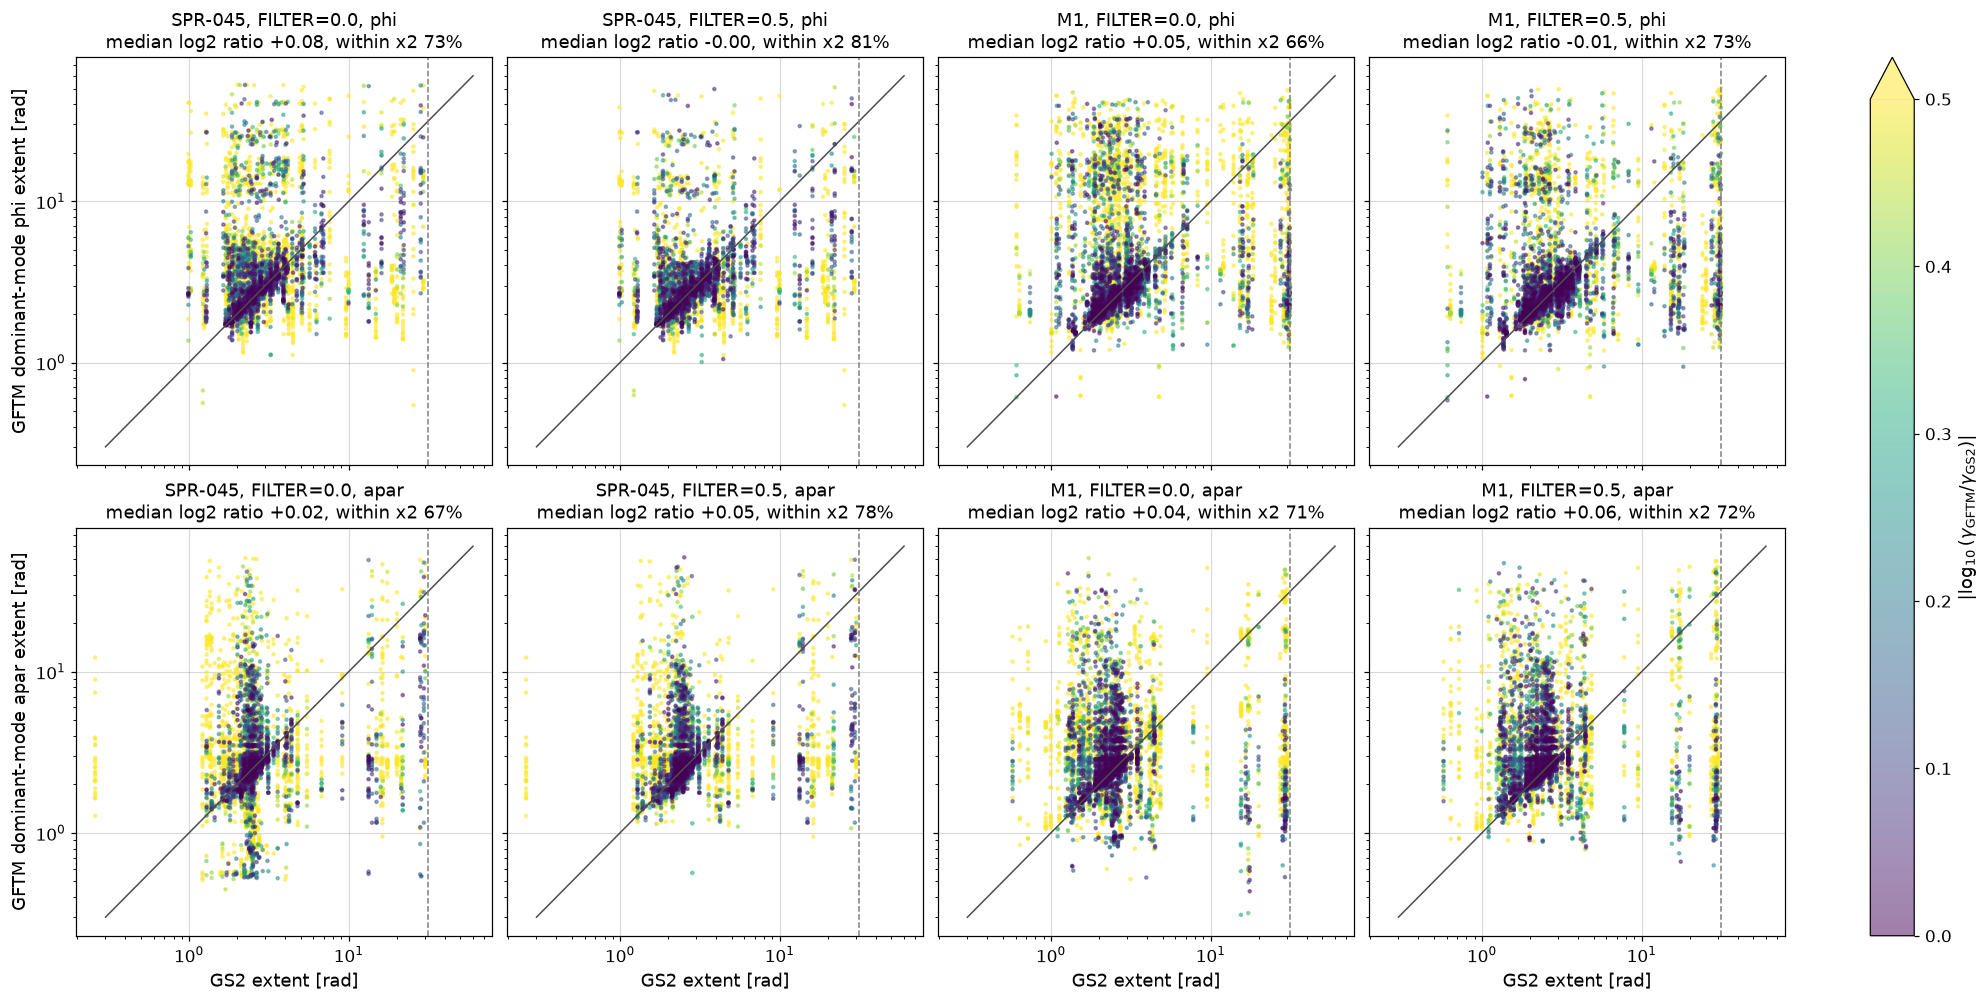

In [36]:
growth_err_max = 0.5   # colour scale limit for |log10(gamma_GFTM/gamma_GS2)| (clipped above; 0.5 = factor ~3)
panels = [(db, arm) for db in cases for arm in ("FILTER=0.0", "FILTER=0.5")]
fig11, axes11 = plt.subplots(len(fields), len(panels), figsize=(18, 9), sharex=True, sharey=True)
for row, f in enumerate(fields):
    for col, (db, arm) in enumerate(panels):
        s = ext_ok[(ext_ok.db == db) & (ext_ok.arm == arm) & (ext_ok.field == f)].sort_values("growth_err", ascending=False)   # accurate on top
        ax = axes11[row, col]
        sc = ax.scatter(s.ext_gs2, s.ext_gftm, c=s.growth_err, cmap="viridis", vmin=0, vmax=growth_err_max, s=4, alpha=0.5)
        ax.plot([0.3, 60], [0.3, 60], color="0.3", lw=1, marker="")
        ax.axvline(2 * gs2_theta_max[db], color="0.5", ls="--", lw=1, marker="")
        ax.set(xscale="log", yscale="log",
               title=f"{db}, {arm}, {f}\nmedian log2 ratio {s.log2_ratio.median():+.2f}, within x2 {(s.log2_ratio.abs() <= 1).mean():.0%}")
    axes11[row, 0].set(ylabel=f"GFTM dominant-mode {f} extent [rad]")
for ax in axes11[-1]:
    ax.set(xlabel="GS2 extent [rad]")
fig11.colorbar(sc, ax=axes11, extend="max", label=r"$|\log_{10}(\gamma_{\rm GFTM}/\gamma_{\rm GS2})|$")
plt.show()

In [37]:
fig11.savefig(ROOT / "Plots" / analysis_name / "fig11_extent_gftm_vs_gs2.png")

## GFTM vs GS2 extent: interpretation

- **Right on average, weak case by case.** The median GFTM/GS2 extent ratio is close to 1 everywhere
  (|median log2 ratio| <= 0.08) and 66-81% of (case, width) pairs are within a factor of 2, but the rank correlation is
  weak (Spearman 0.09-0.34): GFTM's dominant-mode extent tracks GS2's only loosely, with long vertical streaks where
  one GS2 case gets very different GFTM extents across WIDTH.
- **Extent agreement goes with growth-rate accuracy.** Pairs whose extent is within a factor of 2 of GS2 have median
  growth error 0.07-0.21; pairs outside it 0.39-0.60, i.e. 3-5x worse, in every panel. The accurate (dark) points
  sit on the diagonal band; the off-diagonal streaks are mostly large-error (yellow) modes. So when GFTM picks a mode
  with the wrong ballooning structure it also tends to get gamma wrong. This is a diagnostic with the GS2 answer, not
  a usable filter: GFTM alone cannot know the GS2 extent.
- **FILTER=0.5 tightens it,** most visibly for apar: within-x2 rises (SPR-045 phi 73% -> 81%, apar 67% -> 78%), the
  Spearman correlation rises in every panel, and the growth error falls on both sides of the x2 line. The SPR-045
  cluster of short apar extents (< 1 rad, mixed errors) under FILTER=0.0 is removed by FILTER=0.5: the
  short-apar-extent modes and the parity-flagged modes are the same modes.
- Excluded: 20 SPR-045 GS2-unstable cases with non-finite GS2 extent (both fields, all widths), and 38 GFTM MISS
  pairs. GS2 extents are capped by its +-5 pi grid (dashed line); the points piled against it are lower bounds.

# GFTM extent bias vs WIDTH, and an extent oracle

**Bias:** median log2(GFTM / GS2) extent of the dominant mode, per WIDTH (IQR shaded), for both fields and filters.

**Extent oracle:** for each case, pick the WIDTH whose GFTM dominant mode has the extent closest to GS2's
(smallest |log2 ratio|, on phi or on apar), then score that mode's growth rate and frequency. Compared on the same
cases (GS2 extent finite) against: the best single fixed WIDTH; a random WIDTH (all (case, width) pairs pooled); and
the growth / frequency width oracles, which pick WIDTH by the target itself and so bound what any width choice can
do. Done over the width-oracle range (0.3-0.8) and over all 24 widths.

**The extent oracle consults GS2's eigenfunction: it is a bound, not a usable selector.**

## Extent bias and extent oracle: calculate

In [38]:
extent_bias = (ext_ok.groupby(["db", "arm", "field", "width"]).log2_ratio
               .agg(median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)).reset_index())
print("--- median log2(GFTM/GS2) extent per WIDTH ---")
print(extent_bias.pivot(index="width", columns=["db", "arm", "field"], values="median").round(2).to_string())

extent_oracle_ranges = {"0.3-0.8": width_oracle_range, "all widths": (0.0, np.inf)}
rows_eo = []
for (db, arm, f), g in ext_cmp.groupby(["db", "arm", "field"]):
    for label, (lo, hi) in extent_oracle_ranges.items():
        s = g[(g.width >= lo) & (g.width <= hi)]
        dist, gerr, ferr = (s.pivot(index="name", columns="width", values=col) for col in ("log2_ratio", "growth_err", "freq_err"))
        keep = dist.notna().any(axis=1)   # cases with a finite GS2 extent
        D = dist[keep].abs().fillna(np.inf).to_numpy()   # a MISS never wins the oracle
        G, F = gerr[keep].to_numpy(), ferr[keep].to_numpy()
        pick, r = D.argmin(axis=1), np.arange(len(D))
        rows_eo.append(dict(db=db, arm=arm, field=f, widths=label, n=len(D),
                            medlog_random=np.median(G), medlog_best_fixed=np.median(G, axis=0).min(),
                            medlog_extent_oracle=np.median(G[r, pick]), medlog_growth_oracle=np.median(G.min(axis=1)),
                            freq_random=np.median(F), freq_best_fixed=np.median(F, axis=0).min(),
                            freq_extent_oracle=np.median(F[r, pick]), freq_frequency_oracle=np.median(F.min(axis=1)),
                            extent_match=np.median(D[r, pick])))
extent_oracle = pd.DataFrame(rows_eo)
print("\n--- extent oracle (medlog = median |log10 gamma error|; freq = median |omega error|; extent_match = median |log2 ratio| achieved) ---")
print(extent_oracle.round(4).to_string(index=False))

--- median log2(GFTM/GS2) extent per WIDTH ---
db             M1                           SPR-045                       
arm    FILTER=0.0       FILTER=0.5       FILTER=0.0       FILTER=0.5      
field        apar   phi       apar   phi       apar   phi       apar   phi
width                                                                     
0.2000      -0.07 -0.20      -0.00 -0.27      -0.85 -0.01      -0.17 -0.15
0.2297      -0.17 -0.11      -0.11 -0.21      -0.81  0.03      -0.05 -0.17
0.2639      -0.05 -0.07      -0.02 -0.14      -0.83  0.13      -0.15 -0.08
0.3031      -0.12 -0.04      -0.08 -0.10      -0.89  0.15      -0.09 -0.10
0.3482      -0.05 -0.02      -0.03 -0.07      -0.82  0.18      -0.06 -0.04
0.4000      -0.07 -0.01      -0.05 -0.06      -0.67  0.13      -0.15 -0.05
0.4595      -0.06 -0.01      -0.05 -0.04      -0.06  0.01      -0.02 -0.03
0.5279      -0.06 -0.02      -0.05 -0.05      -0.12  0.01      -0.09 -0.02
0.6063      -0.01 -0.02      -0.00 -0.03      -0.00 -

## Extent bias: plot

Median log2(GFTM / GS2) extent of the dominant mode vs WIDTH, IQR shaded; 0 = unbiased, +-1 = factor 2.

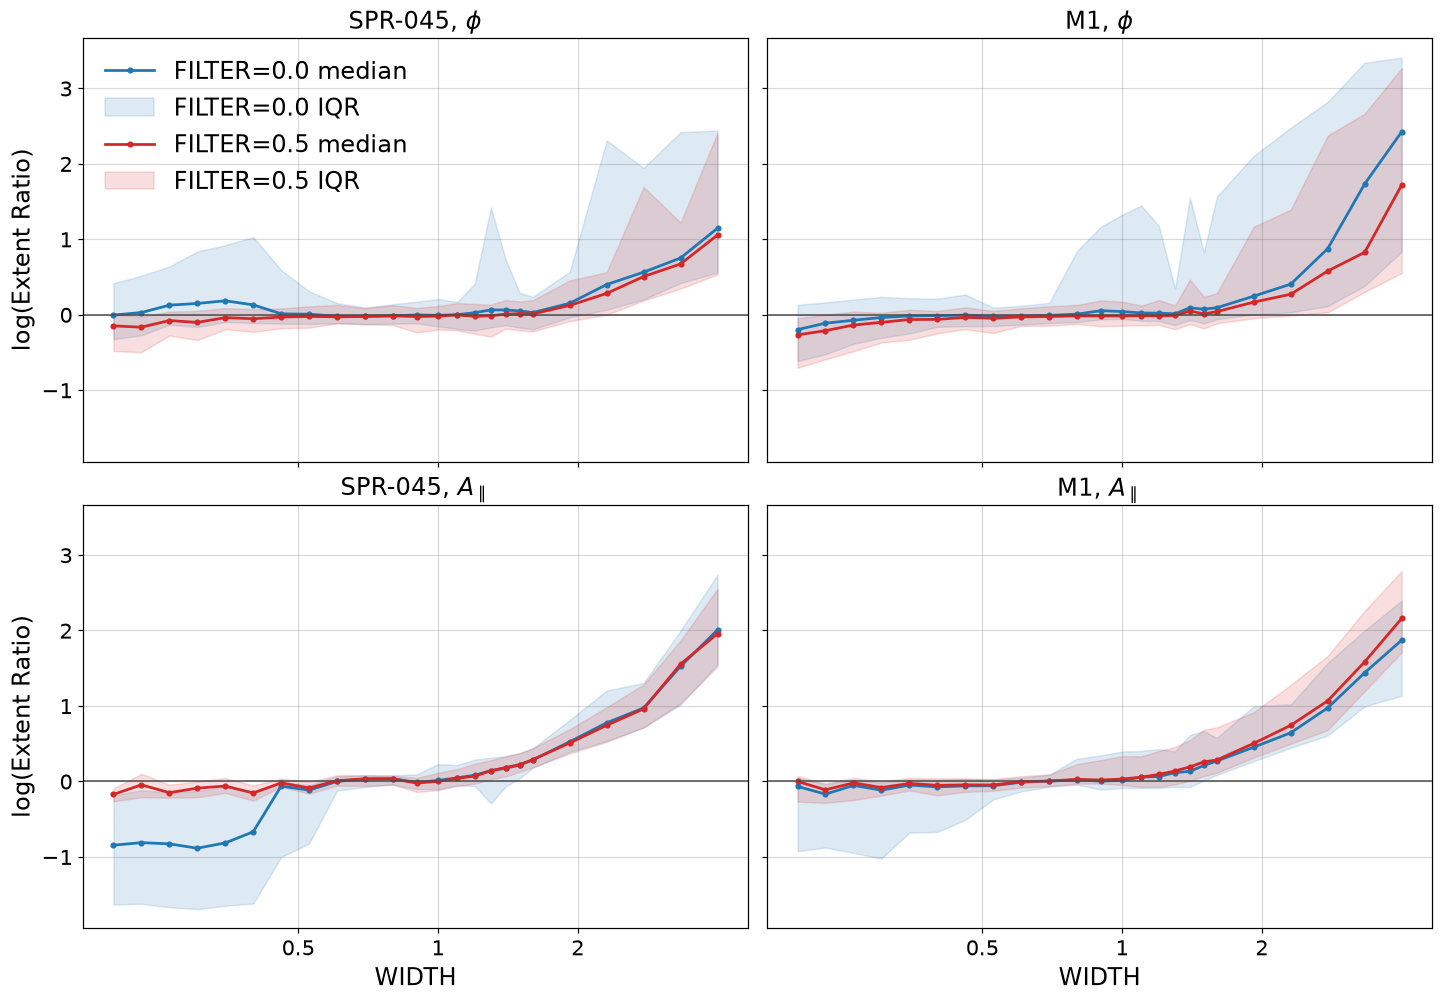

In [68]:
from matplotlib.ticker import StrMethodFormatter

fig12, axes12 = plt.subplots(len(fields), len(cases), figsize=(13, 9), sharex=True, sharey=True, squeeze=False)
field_labels = {"phi": r"$\phi$", "apar": r"$A_\parallel$", "bpar": r"$B_\parallel$"}

for row, f in enumerate(fields):
    for col, db in enumerate(cases):
        ax = axes12[row, col]
        for arm, colour in (("FILTER=0.0", "C0"), ("FILTER=0.5", "C3")):
            s = extent_bias[(extent_bias.db == db) & (extent_bias.arm == arm) & (extent_bias.field == f)]
            ax.plot(s.width, s["median"], color=colour, marker="o", ms=3, label=f"{arm} median")
            ax.fill_between(s.width, s.q25, s.q75, color=colour, alpha=0.15, label=f"{arm} IQR")
        ax.axhline(0, color="0.3", lw=1, marker="")
        ax.set_xscale("log")
        ax.set_title(f"{db}, {field_labels[f]}", fontsize=16)
        ax.tick_params(axis="both", labelsize=14)
    axes12[row, 0].set_ylabel("log(Extent Ratio)", fontsize=16)

for ax in axes12[-1]:
    ax.set_xlabel("WIDTH", fontsize=16)

axes12[0, 0].legend(fontsize=16)
ax = axes12[0, 0]
lims = ax.get_xlim()
ax.set_xticks([0.5, 1, 2, 5, 10])
ax.set_xlim(lims)
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
ax.minorticks_off()
plt.show()

In [40]:
fig12.savefig(ROOT / "Plots" / analysis_name / "fig12_extent_bias_vs_width.png")

## Extent bias and extent oracle: interpretation

- **GFTM's extent bias is set by WIDTH.** For WIDTH ~0.45-1.6 the median log2(GFTM/GS2) is within +-0.1 (extents
  agree to <7%), and with FILTER=0.5 the IQR there is narrow. Above WIDTH ~1.6 GFTM's extent grows monotonically too
  long: +0.5 (x1.4) at 1.9, +1 (x2) near 2.8, +1 to +2.4 (x2-5) at 4.0. Below ~0.45 it is slightly short for phi
  (-0.1 to -0.3), and for SPR-045 apar with FILTER=0.0 strongly short (-0.85, x0.55): the short-apar spurious modes,
  which FILTER=0.5 removes (red line back near 0).
- **The extent oracle does not help.** Picking, per case, the WIDTH whose dominant mode matches the GS2 extent works
  as an extent match (median |log2 ratio| achieved 0.01-0.06, i.e. 1-4%), but not as a predictor: over 0.3-0.8 it is
  within ~10% of the best fixed width in growth medlog (e.g. M1 FILTER=0.0 apar 0.067 vs 0.071; SPR-045 0.117 vs 0.108,
  worse) and in frequency medAE; over all 24 widths it is worse than the best fixed width (0.107 vs 0.071; 0.140 vs
  0.108), landing between a random width and the best fixed one. It is nowhere near the growth / frequency width
  oracles (0.01-0.04 growth, 0.001-0.017 frequency).
- **Likely reason (not tested directly).** Across the WIDTH range where GFTM is least wrong (~0.45-1.6), its
  dominant-mode extent already matches GS2, so extent cannot discriminate between those widths; the remaining
  gamma/omega error there is not an extent error. Outside that range, a matching extent can be reached at a width where
  gamma is still wrong. The x2-extent/accuracy link in fig 11 is then probably this WIDTH bias plus the gross spurious
  modes, not a fine-tuning signal.
- Note: these scores use the cases with a finite GS2 extent (200 SPR-045, 252 M1), so fixed-width values differ
  slightly from the width-oracle table for SPR-045.

# Does GFTM capture the extended KBMs GS2 finds?

In the WIDTH band where GFTM's extent is unbiased on average (`best_width_range`), are the cases whose GS2
eigenfunction is **more extended** in theta captured? Cases are binned by GS2 phi extent (`gs2_extent_bins`); per bin:
the extent bias (median log2 GFTM/GS2), the fraction where GFTM is more than 2x too short, and the growth and frequency
errors. Then, per bin, the error vs WIDTH over all 24 widths: do extended cases want a larger WIDTH?

Caveat: GS2's output grid is +-5 pi, so extents in the top bin are lower bounds (capped at 10 pi ~ 31 rad); GFTM's
grid is +-9 pi.

## Extended KBMs: calculate

In [41]:
best_width_range = (0.45, 1.6)          # WIDTH band where GFTM's extent is unbiased on average (fig 12)
gs2_extent_bins = [0, 3, 6, 12, 32]     # GS2 phi extent bins [rad]; the top bin reaches the 10 pi grid cap

ext_phi = ext_cmp[(ext_cmp.field == "phi") & np.isfinite(ext_cmp.ext_gs2)]
ext_phi = ext_phi.assign(gs2_bin=pd.cut(ext_phi.ext_gs2, gs2_extent_bins, right=False))

print(f"--- WIDTH {best_width_range[0]}-{best_width_range[1]}: GFTM dominant mode vs GS2, by GS2 phi extent ---")
in_band = ext_phi[ext_phi.width.between(*best_width_range)]
print(in_band.groupby(["db", "arm", "gs2_bin"], observed=True).agg(
    cases=("name", "nunique"), median_gs2_extent=("ext_gs2", "median"), median_gftm_extent=("ext_gftm", "median"),
    median_log2_ratio=("log2_ratio", "median"), frac_gftm_short_x2=("log2_ratio", lambda x: (x < -1).mean()),
    medlog=("growth_err", "median"), freq_medAE=("freq_err", "median")).round(3).to_string())

by_width = (ext_phi.groupby(["db", "arm", "gs2_bin", "width"], observed=True)
            .agg(median_log2_ratio=("log2_ratio", "median"), medlog=("growth_err", "median"), freq_medAE=("freq_err", "median"))
            .reset_index())
print("\n--- per GS2 extent bin: WIDTH with the lowest growth medlog / freq medAE over all 24 widths ---")
for key, g in by_width.groupby(["db", "arm", "gs2_bin"], observed=True):
    b = g[g.width.between(*best_width_range)]
    print(f"{key[0]:8s} {key[1]} GS2 extent {str(key[2]):10s}: growth best W={g.width[g.medlog.idxmin()]:g} "
          f"({g.medlog.min():.3f}; best in band {b.medlog.min():.3f}) | freq best W={g.width[g.freq_medAE.idxmin()]:g} "
          f"({g.freq_medAE.min():.4f}; best in band {b.freq_medAE.min():.4f})")

--- WIDTH 0.45-1.6: GFTM dominant mode vs GS2, by GS2 phi extent ---
                             cases  median_gs2_extent  median_gftm_extent  median_log2_ratio  frac_gftm_short_x2  medlog  freq_medAE
db      arm        gs2_bin                                                                                                          
M1      FILTER=0.0 [0, 3)      149              2.166               2.454              0.089               0.000   0.105       0.071
                   [3, 6)       63              3.483               3.407             -0.044               0.018   0.069       0.042
                   [6, 12)       9              7.127               7.818              0.125               0.256   0.501       0.725
                   [12, 32)     31             28.089               4.748             -2.359               0.794   0.555       0.997
        FILTER=0.5 [0, 3)      149              2.166               2.367              0.050               0.000   0.076       0.052


## Extended KBMs: plot

FILTER=0.5, per GS2 phi extent bin (colour, short to long): extent bias, growth error and frequency error vs WIDTH;
the grey band is `best_width_range`.

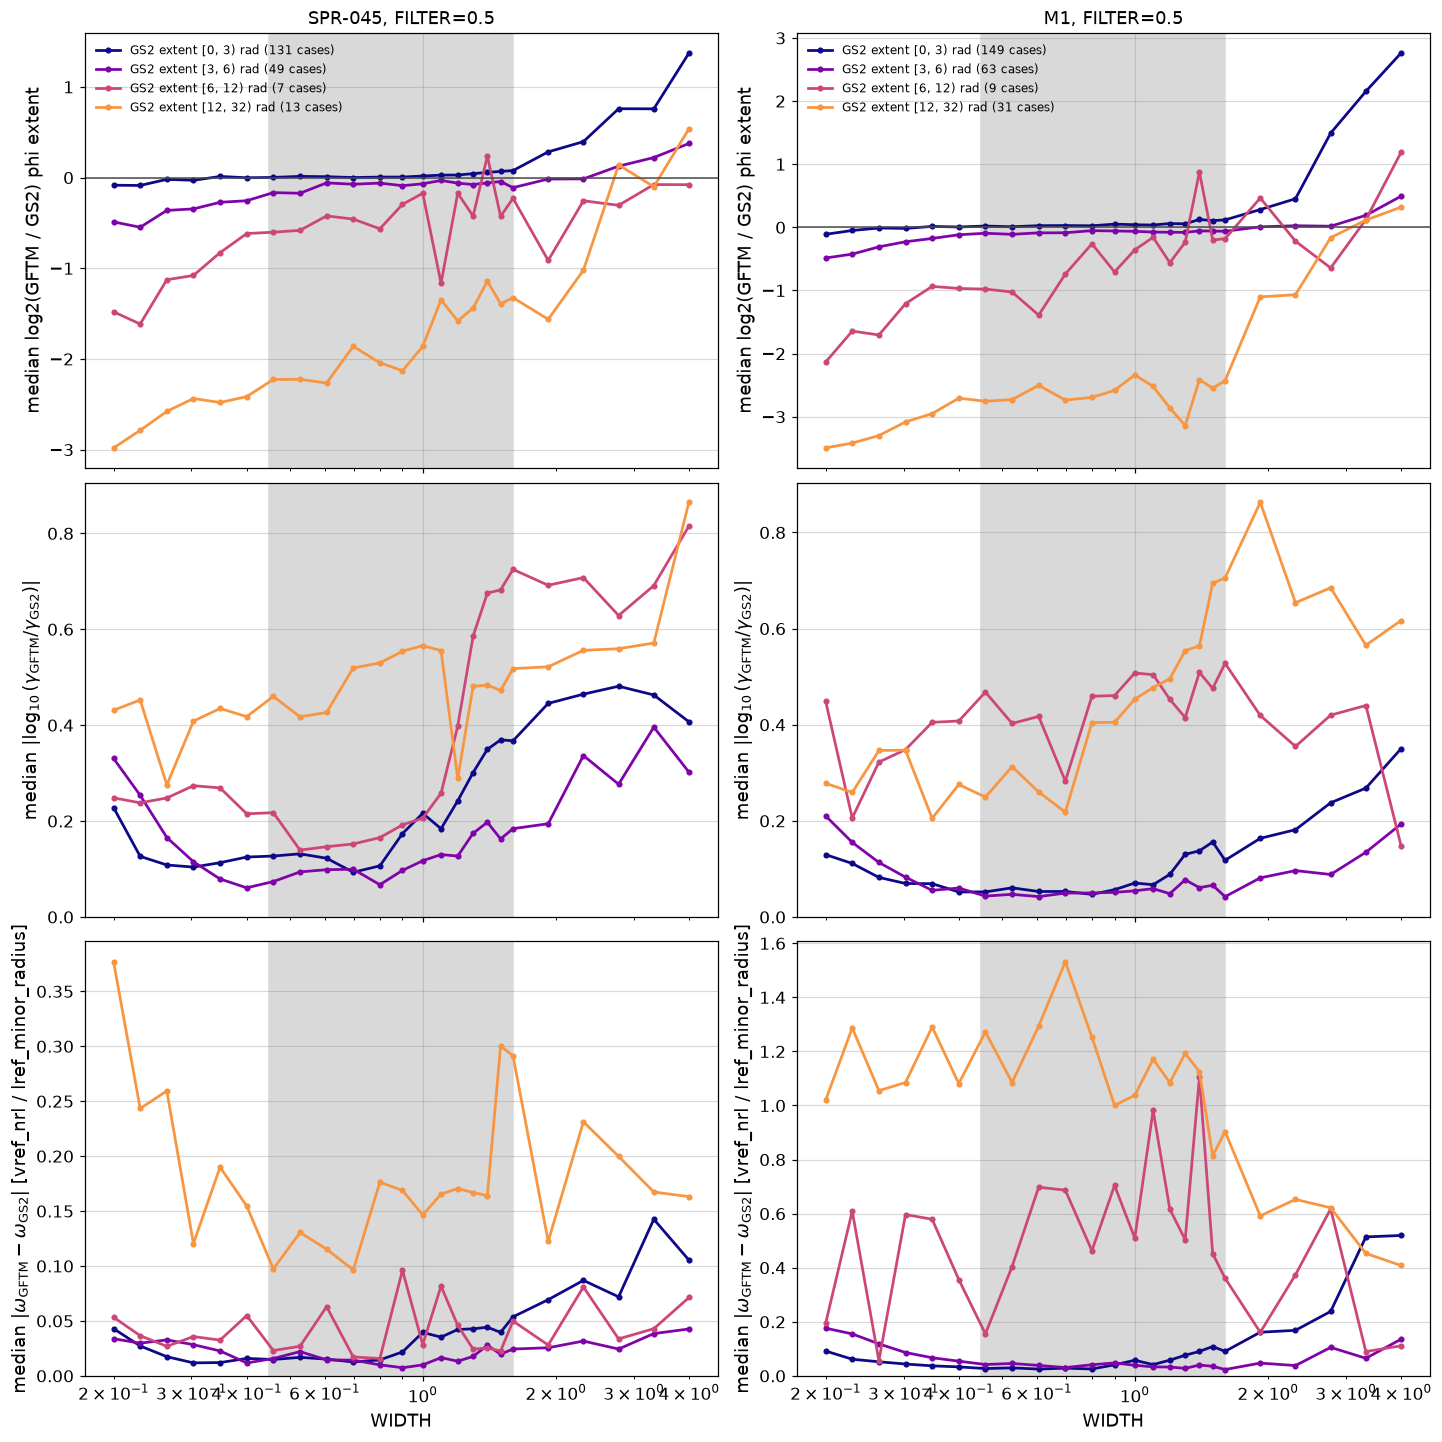

In [42]:
bins = list(by_width.gs2_bin.cat.categories)
bin_colour = {b: plt.get_cmap("plasma")(i / len(bins)) for i, b in enumerate(bins)}
fig13, axes13 = plt.subplots(3, len(cases), figsize=(13, 13), sharex=True, squeeze=False)
for col, db in enumerate(cases):
    for b in bins:
        s = by_width[(by_width.db == db) & (by_width.arm == "FILTER=0.5") & (by_width.gs2_bin == b)]
        n = ext_phi[(ext_phi.db == db) & (ext_phi.gs2_bin == b)].name.nunique()
        for row, m in enumerate(("median_log2_ratio", "medlog", "freq_medAE")):
            axes13[row, col].plot(s.width, s[m], color=bin_colour[b], marker="o", ms=3, label=f"GS2 extent {b} rad ({n} cases)")
    for ax in axes13[:, col]:
        ax.axvspan(*best_width_range, color="0.85", zorder=0)
    axes13[0, col].axhline(0, color="0.3", lw=1, marker="")
    axes13[0, col].set(xscale="log", title=f"{db}, FILTER=0.5", ylabel="median log2(GFTM / GS2) phi extent")
    axes13[1, col].set(ylabel=r"median $|\log_{10}(\gamma_{\rm GFTM}/\gamma_{\rm GS2})|$", ylim=(0, None))
    axes13[2, col].set(xlabel="WIDTH", ylabel=rf"median $|\omega_{{\rm GFTM}}-\omega_{{\rm GS2}}|$ [{frequency_units}]", ylim=(0, None))
    axes13[0, col].legend(fontsize=8)
plt.show()

In [43]:
fig13.savefig(ROOT / "Plots" / analysis_name / "fig13_extended_kbms_vs_width.png")

## Extended KBMs: interpretation

**Revised by the next section:** the extended GS2 modes (>= 12 rad) turn out to be mostly microtearing-like on M1 and
unconverged near-marginal runs on SPR-045, not well-resolved KBMs. The measurements below stand; read "extended
KBMs" as "extended GS2 modes".

- **In the unbiased WIDTH band (0.45-1.6), GFTM does not reproduce the extended GS2 modes.** For compact GS2 modes
  (phi extent < 6 rad, 392 of 452 cases) GFTM's extent matches (median log2 ratio -0.08 to +0.09, almost never >x2
  short). For the most extended GS2 modes (12-31 rad; 13 SPR-045 and 31 M1 cases) GFTM's dominant mode is 3-6x too
  compact (GS2 median 20-28 rad vs GFTM 3-6 rad; 68-88% more than 2x short), and the 6-12 rad bin (7 + 9 cases) is
  ~1.4x short. FILTER=0.5 does not help here (slightly shorter still).
- **Those cases carry large errors.** Growth medlog 0.45-0.56 (vs 0.05-0.21 for compact modes) and, on M1, frequency
  errors ~1.0-1.1 (vs 0.04-0.07): GFTM is finding a different, compact mode, not a poorly resolved version of GS2's.
- **A larger WIDTH does not rescue them.** GFTM's extent for these cases only approaches GS2's at WIDTH >= 2-3 (fig 13,
  top), but the growth error there is no better, often worse (best growth WIDTH for the 12-31 rad bin is 0.26-0.46).
  Frequency improves at WIDTH 4 on M1 (0.41 vs 0.81 in band) but stays far above the compact-mode error.
- Caveats: small bins (7-31 cases per database). GS2 extents in the top bin are lower bounds (+-5 pi grid).

# Are the extended GS2 modes resolved, and are they KBMs?

The extended bin is small, so each GS2 eigenfunction with phi extent >= `extended_threshold` is plotted (|phi| and
|apar|, each normalised to its own peak, log scale so the tails at the grid edge are visible). Diagnostics, compared
with the compact GS2-unstable cases:

- **Box length**: peak |field| within `edge_window` of the theta-grid edge, relative to the field's peak. A mode that
  has not decayed at the edge is truncated by GS2's ballooning box (and its extent is a lower bound).
- **Convergence**: GS2's `growth_rate_tolerance`.
- **KBM signature**: ballooning parity (phi even, apar odd: even-part fraction of the power, using theta -> -theta on
  GS2's symmetric grid), max|apar|/max|phi| in pyro's normalisation, the apar share of the heat flux (summed over
  species), and the frequency sign against the compact population (pyro's sign convention, same for both groups).

## Extended GS2 modes: calculate

In [44]:
extended_threshold = 12.0   # rad: GS2 phi extent defining an extended mode (top bin of gs2_extent_bins)
edge_window = 1.0           # rad: 'edge' = |theta| within this of the grid end
edge_max = 0.1              # |phi| at the edge above this fraction of its peak: not decayed inside GS2's box
gamma_tol_max = 0.1         # GS2 growth_rate_tolerance above this: treated as not converged (compact medians 0.00-0.02)

rows_gs2 = []
for db in cases:
    ref = gs2[db].data
    theta = ref.theta.values
    assert np.allclose(theta, -theta[::-1]), f"{db}: GS2 theta grid not symmetric, parity check invalid"
    field_index = {f: list(ref.field.values).index(f) for f in ("phi", "apar")}
    ef = mag(ref.eigenfunctions.transpose("sample", "field", "theta"))
    heat = mag(ref.heat.sum("species").transpose("sample", "field"))
    edge = np.abs(theta) >= np.abs(theta).max() - edge_window
    for s in np.where(np.isin(ref.sample_name.values, cases_data[db, widths[0]]["names"]))[0]:   # GS2-unstable cases
        row = dict(db=db, name=ref.sample_name.values[s], gamma=float(mag(ref.growth_rate)[s]),
                   omega=float(mag(ref.mode_frequency)[s]), gamma_tol=float(mag(ref.growth_rate_tolerance)[s]),
                   beta=float(ref.beta.values[s]), shat=float(ref.shat.values[s]), q=float(ref.q.values[s]))
        with np.errstate(invalid="ignore"):   # the 20 SPR-045 cases without GS2 eigenfunctions give NaN here
            row["em_heat_frac"] = heat[s, field_index["apar"]] / heat[s].sum()
            for f in ("phi", "apar"):
                e = ef[s, field_index[f]]
                even, odd = e + e[::-1], e - e[::-1]
                row[f"ext_{f}"] = float(mag(ref.extent.sel(field=f))[s])
                row[f"edge_{f}"] = np.abs(e[edge]).max() / np.abs(e).max()
                row[f"even_frac_{f}"] = np.sum(np.abs(even) ** 2) / (np.sum(np.abs(even) ** 2) + np.sum(np.abs(odd) ** 2))
            row["apar_over_phi"] = np.abs(ef[s, field_index["apar"]]).max() / np.abs(ef[s, field_index["phi"]]).max()
        rows_gs2.append(row)
gs2_diag = pd.DataFrame(rows_gs2)
gs2_diag = gs2_diag.assign(
    group=np.where(gs2_diag.ext_phi >= extended_threshold, "extended", np.where(np.isfinite(gs2_diag.ext_phi), "compact", "no extent")),
    parity=np.where(gs2_diag.even_frac_phi > 0.5, "twisting (phi even)", "tearing (phi odd)"),
    converged=gs2_diag.gamma_tol <= gamma_tol_max, decayed=gs2_diag.edge_phi <= edge_max)

cols = ["gamma", "omega", "gamma_tol", "edge_phi", "edge_apar", "even_frac_phi", "even_frac_apar", "apar_over_phi",
        "em_heat_frac", "beta", "shat", "q"]
print("--- medians by group (GS2-unstable cases) ---")
print(gs2_diag.groupby(["db", "group"])[cols].median().assign(n=gs2_diag.groupby(["db", "group"]).size()).round(3).to_string())
print("\n--- fraction with omega < 0, by group ---")
print(gs2_diag.groupby(["db", "group"]).omega.apply(lambda x: (x < 0).mean()).round(2).to_string())
has_ef = gs2_diag.group != "no extent"
print("\n--- parity / converged / decayed within the box: counts by group ---")
print(pd.crosstab([gs2_diag[has_ef].db, gs2_diag[has_ef].group],
                  [gs2_diag[has_ef].parity, gs2_diag[has_ef].converged.map({True: "converged", False: "not converged"}),
                   gs2_diag[has_ef].decayed.map({True: "decayed", False: "at box edge"})]).to_string())
print("\n--- extended cases ---")
print(gs2_diag[gs2_diag.group == "extended"].sort_values(["db", "ext_phi"])[["db", "name", "parity", "ext_phi", "ext_apar"] + cols]
      .round(3).to_string(index=False))

/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_kbm_extent/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_kbm_extent/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


--- medians by group (GS2-unstable cases) ---
                   gamma  omega  gamma_tol  edge_phi  edge_apar  even_frac_phi  even_frac_apar  apar_over_phi  em_heat_frac   beta   shat      q    n
db      group                                                                                                                                        
M1      compact    0.204  0.301      0.000     0.008      0.000            1.0             0.0          0.136        -0.061  0.026  2.719  3.255  221
        extended   0.030 -0.615      0.003     0.490      0.058            0.0             1.0          0.870         0.985  0.050  1.057  3.654   31
SPR-045 compact    0.031  0.017      0.019     0.005      0.000            1.0             0.0          1.092        -0.066  0.043  2.563  3.282  187
        extended   0.012 -0.007      1.326     0.098      0.034            1.0             0.0          0.189        -0.045  0.026  0.190  4.309   13
        no extent  0.768  0.104      0.000       NaN  

### Pyrokinetics tearing parameter from the individual GS2 runs

`FieldLine.compute_linear_tearing_parameter` = |integral A_par dl| / integral |A_par| dl along the field line (~1 tearing
parity, ~0 twisting). It needs each run's geometry and `nperiod`, which the cube does not carry, so every GS2-unstable
case is loaded from its own run directory (`gs2.in`, with `gs2.out.nc` read alongside; final time slice). Read-only;
failures are recorded, not dropped. ~2 s per run.

In [ ]:
tearing_threshold = 0.5   # pyro tearing parameter above this: tearing parity

from general_analysis import mode_classification as mc
from pyrokinetics import PyroHypercube

rows_tp = []
for db, case in cases.items():
    base = data_root / "GS2" / run_template / project / case / scan_information["GS2"]
    # FINAL-time cube: the tail-averaged one above is not the field T is defined on
    cube_dir = base / "pyro_cube"
    gs2_scan = PyroHypercube(pyroscan_json=cube_dir / "pyroscan.json", load_base_pyro=True)
    mc.attach_legacy_funcs(gs2_scan)   # this json predates parameter_func serialisation: re-attach the KBM-cube deck rules
    # R4: per-sample theta grids, held NaN-padded in cube_eigenfunctions.nc
    gs2_scan.load_gk_output(netcdf_file=cube_dir / ("cube_eigenfunctions.nc" if (cube_dir / "cube_eigenfunctions.nc").exists() else "cube.nc"))
    gs2_output = gs2_scan.gk_output.data
    ind = mc.indicators(gs2_scan, gs2_output).to_dataframe().set_index("sample_name")
    numerics = gs2_scan.base_pyro.numerics   # nperiod/ntheta are not scanned
    for name in gs2_diag[gs2_diag.db == db].name:
        rows_tp.append(dict(db=db, name=name, tearing_parameter=ind["T"].get(name, np.nan), nperiod=numerics.nperiod, ntheta=numerics.ntheta,
                            error="" if name in ind.index else "not in the final-time cube"))
tearing = pd.DataFrame(rows_tp)
print("runs:", len(tearing), "| not in cube:", int((tearing.error != "").sum()),
      "| tearing parameter not finite:", int(((tearing.error == "") & ~np.isfinite(tearing.tearing_parameter)).sum()))
print(tearing[(tearing.error != "") | ~np.isfinite(tearing.tearing_parameter)].to_string(index=False))
print("nperiod / ntheta used:", tearing.groupby(["db", "nperiod", "ntheta"]).size().to_dict())

In [ ]:
gs2_diag = gs2_diag.drop(columns=[c for c in ("tearing_parameter", "nperiod") if c in gs2_diag]).merge(
    tearing[["db", "name", "tearing_parameter", "nperiod"]], on=["db", "name"], how="left")
gs2_diag = gs2_diag.assign(pyro_parity=np.where(gs2_diag.tearing_parameter > tearing_threshold, "tearing",
                                                np.where(gs2_diag.tearing_parameter.notna(), "twisting", "failed")))

print(f"--- pyro tearing parameter > {tearing_threshold}: counts by group ---")
print(pd.crosstab([gs2_diag.db, gs2_diag.group], gs2_diag.pyro_parity).to_string())
has_ef = (gs2_diag.group != "no extent") & gs2_diag.tearing_parameter.notna()
same = (gs2_diag.pyro_parity == np.where(gs2_diag.even_frac_phi > 0.5, "twisting", "tearing"))[has_ef]
print(f"\npyro parity agrees with the even-fraction label in {same.sum()}/{len(same)} cases with GS2 eigenfunctions")
print(gs2_diag[has_ef & ~same][["db", "name", "group", "parity", "even_frac_phi", "tearing_parameter"]].round(3).to_string(index=False))
print("\n--- tearing parameter quantiles by group ---")
print(gs2_diag.groupby(["db", "group"]).tearing_parameter.quantile([0.1, 0.5, 0.9]).unstack().round(3).to_string())
print("\n--- extended cases ---")
print(gs2_diag[gs2_diag.group == "extended"].sort_values(["db", "ext_phi"])[
    ["db", "name", "ext_phi", "parity", "tearing_parameter", "pyro_parity", "nperiod", "omega", "em_heat_frac", "converged", "decayed"]]
      .round(3).to_string(index=False))

--- pyro tearing parameter > 0.5: counts by group ---
pyro_parity        failed  tearing  twisting
db      group                               
M1      compact         0        3       218
        extended        0       22         9
SPR-045 compact         0        0       187
        extended        0        0        13
        no extent       2        0        18

pyro parity agrees with the even-fraction label in 451/452 cases with GS2 eigenfunctions
db          name    group            parity  even_frac_phi  tearing_parameter
M1 iteration_169 extended tearing (phi odd)            0.0              0.426

--- tearing parameter quantiles by group ---
                   0.1   0.5    0.9
db      group                      
M1      compact    0.0  0.00  0.000
        extended   0.0  0.79  0.880
SPR-045 compact    0.0  0.00  0.001
        extended   0.0  0.00  0.012
        no extent  0.0  0.00  0.000

--- extended cases ---
     db          name  ext_phi              parity  tearing_par

## Extended GS2 modes: plot

One figure per database; one panel per extended case, sorted by phi extent. Real (solid) and imaginary (dashed) parts
of phi and apar, each divided by its own peak |field|, after one common phase rotation that makes phi's peak real and
positive (so the phi-apar relative phase is kept). Dotted lines mark the `edge_window` at each end of GS2's theta grid.
Title: pyro tearing parameter (TP; ~1 tearing, ~0 twisting), gamma, omega, phi extent, phi/apar edge amplitude, GS2
growth-rate tolerance. Fig 15: tearing parameter vs GS2 phi extent for all GS2-unstable cases.

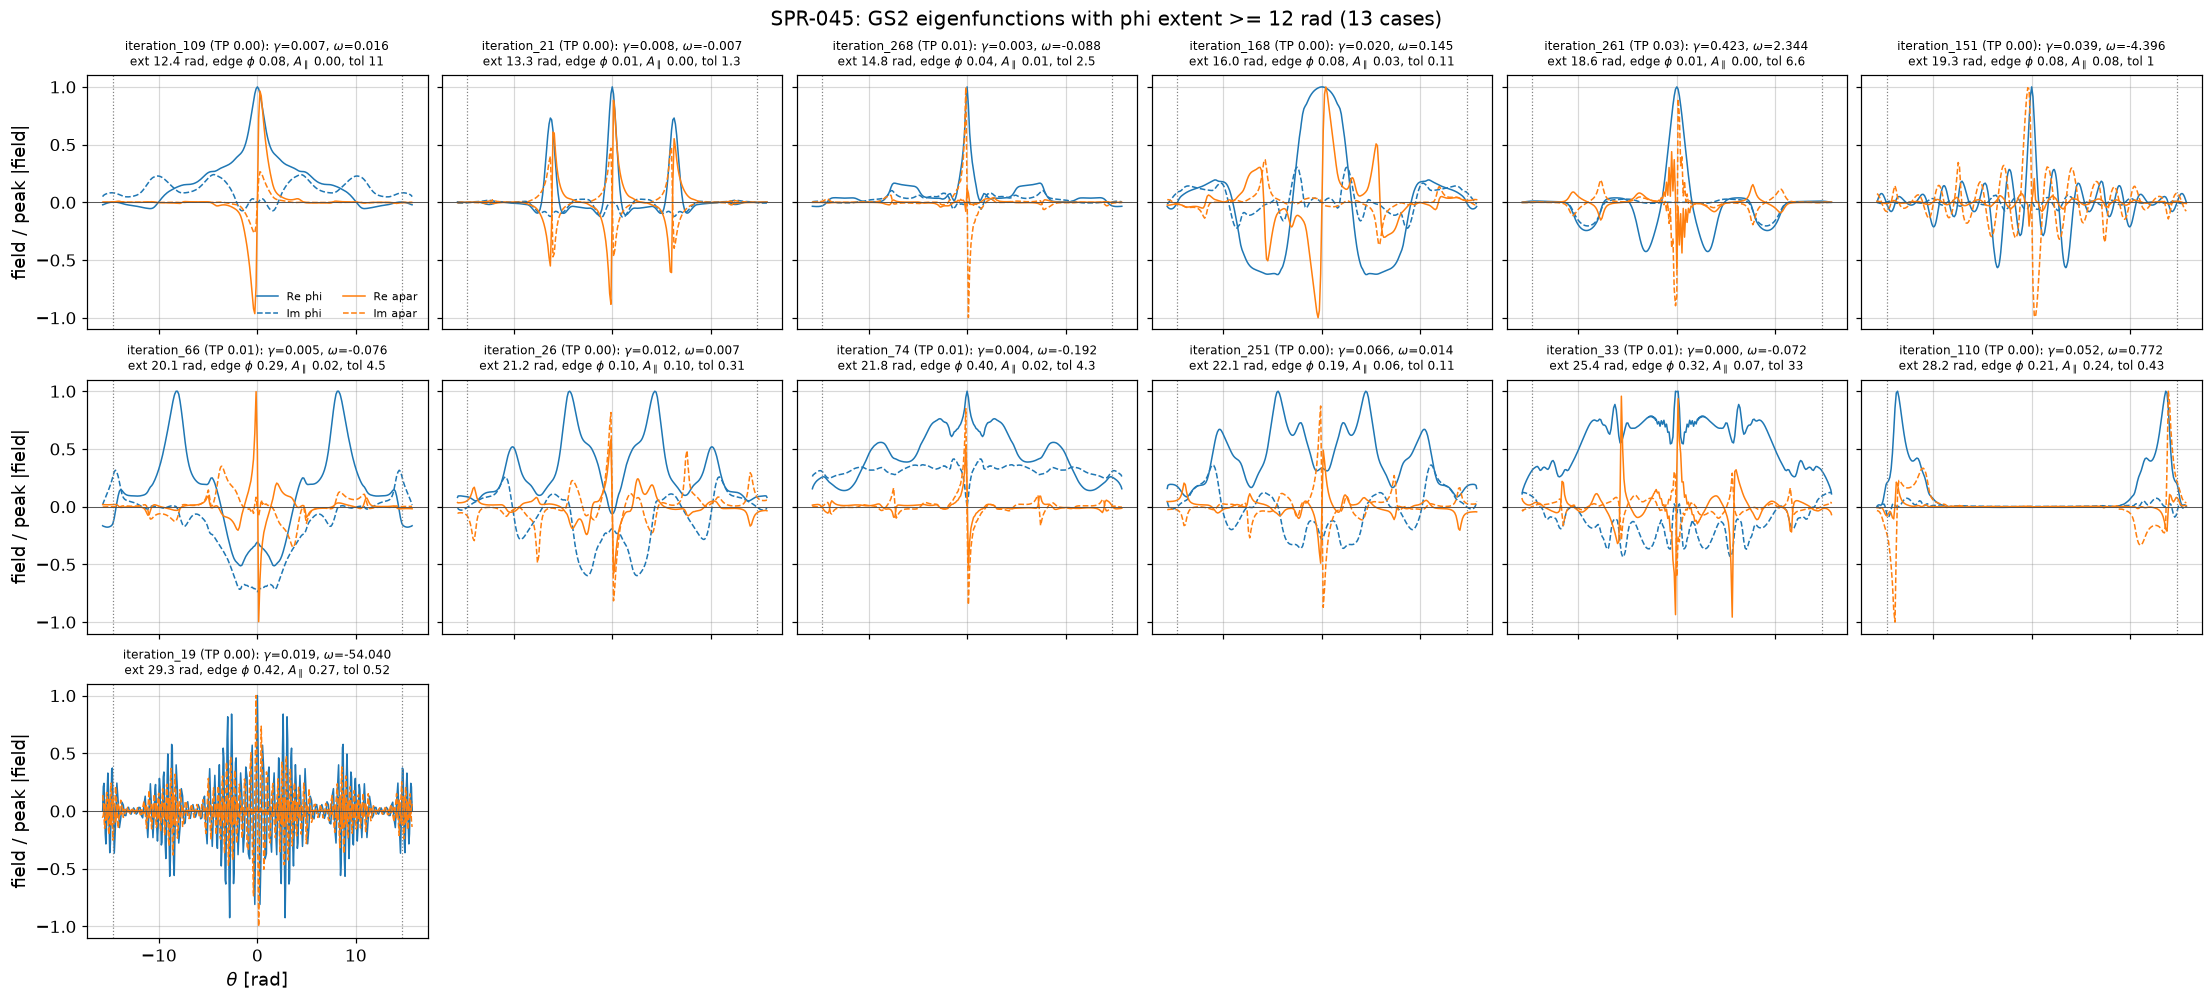

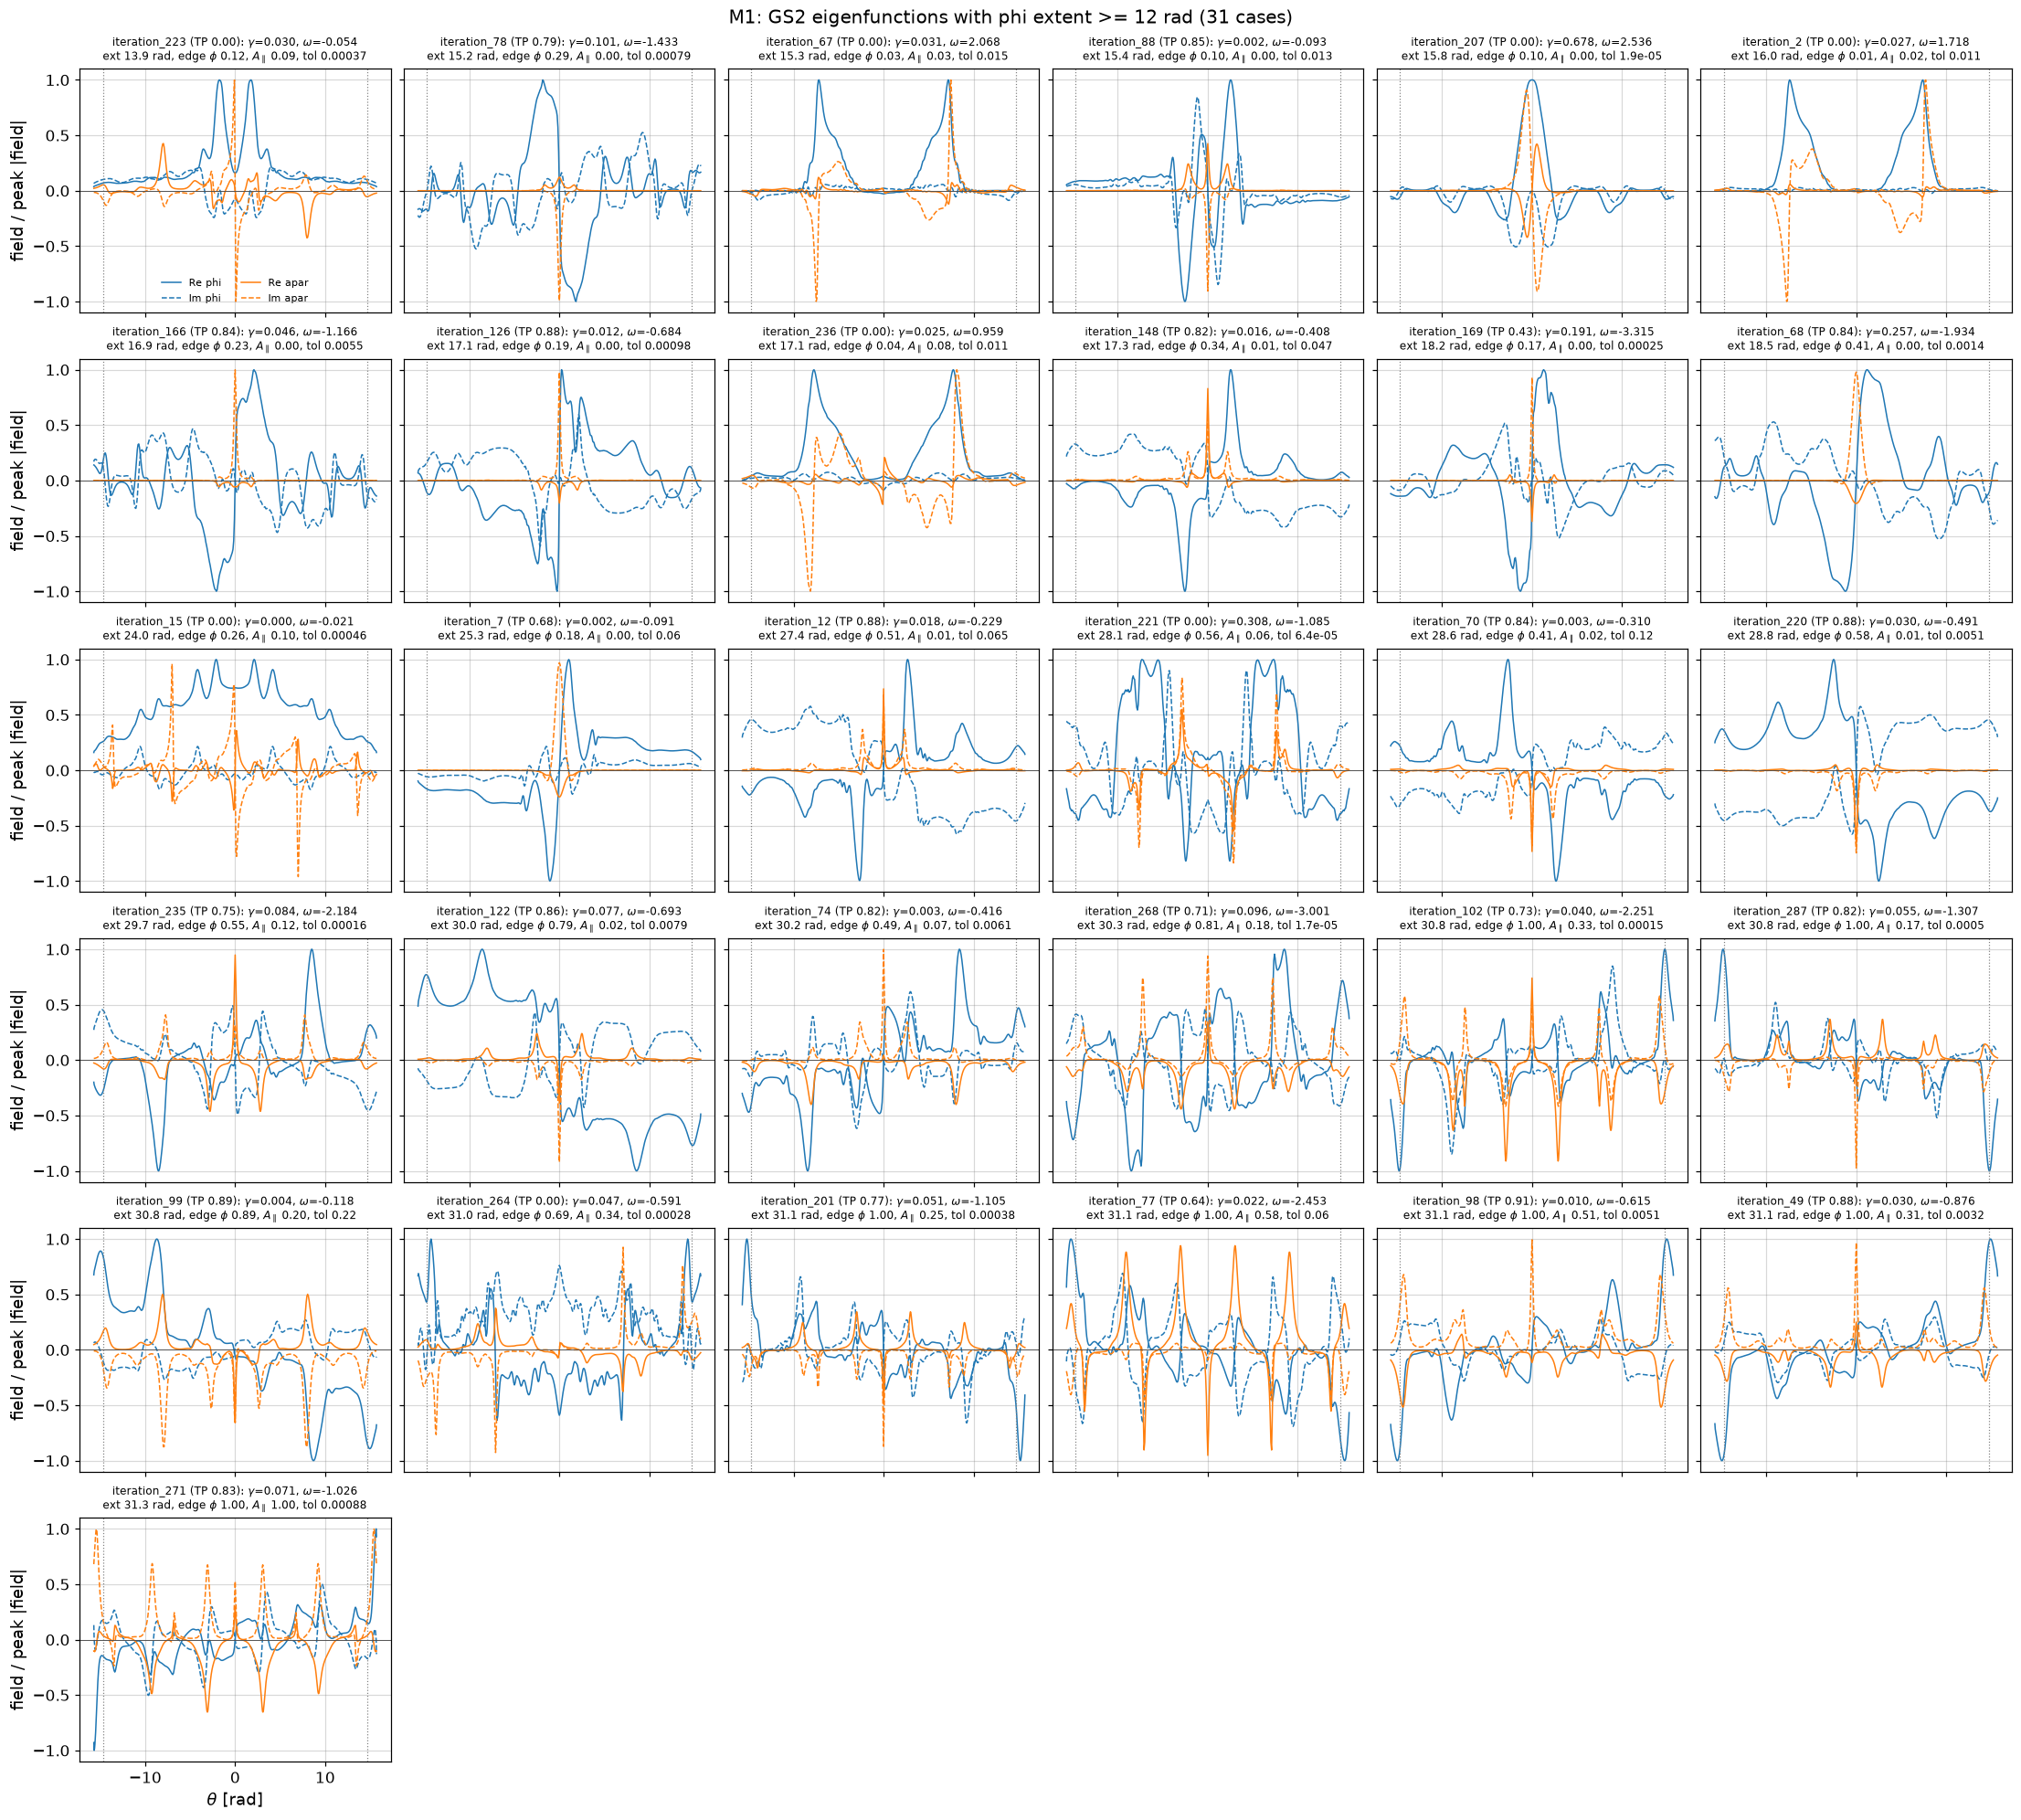

In [ ]:
fig14 = {}
for db in cases:
    ref = gs2[db].data
    ext_cases = gs2_diag[(gs2_diag.db == db) & (gs2_diag.group == "extended")].sort_values("ext_phi")
    ncols = 6
    nrows = int(np.ceil(len(ext_cases) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3 * nrows), sharex=True, sharey=True, squeeze=False)
    theta_edge = np.abs(ref.theta.values).max()
    for ax, (_, c) in zip(axes.flat, ext_cases.iterrows()):
        s = int(np.where(ref.sample_name.values == c["name"])[0][0])
        e = {f: mag(ref.eigenfunctions.sel(field=f).isel(sample=s)) for f in ("phi", "apar")}
        rotation = np.exp(-1j * np.angle(e["phi"][np.abs(e["phi"]).argmax()]))   # phi peak real and positive; same rotation for apar
        for f, colour in (("phi", "C0"), ("apar", "C1")):
            z = e[f] * rotation / np.abs(e[f]).max()
            ax.plot(ref.theta, z.real, color=colour, ls="-", marker="", lw=1, label=f"Re {f}")
            ax.plot(ref.theta, z.imag, color=colour, ls="--", marker="", lw=1, label=f"Im {f}")
        for x in (-theta_edge + edge_window, theta_edge - edge_window):
            ax.axvline(x, color="0.5", ls=":", lw=0.8, marker="")
        ax.axhline(0, color="0.3", lw=0.6, marker="")
        ax.set(ylim=(-1.1, 1.1),
               title=f"{c['name']} (TP {c.tearing_parameter:.2f}): $\\gamma$={c.gamma:.3f}, $\\omega$={c.omega:.3f}\n"
                     f"ext {c.ext_phi:.1f} rad, edge $\\phi$ {c.edge_phi:.2f}, $A_\\parallel$ {c.edge_apar:.2f}, tol {c.gamma_tol:.2g}")
        ax.title.set_fontsize(8)
    for ax in axes.flat[len(ext_cases):]:
        ax.set_visible(False)
    for ax in axes[-1]:
        ax.set(xlabel=r"$\theta$ [rad]")
    for ax in axes[:, 0]:
        ax.set(ylabel="field / peak |field|")
    axes[0, 0].legend(fontsize=7, ncols=2)
    fig.suptitle(f"{db}: GS2 eigenfunctions with phi extent >= {extended_threshold:g} rad ({len(ext_cases)} cases)")
    fig14[db] = fig
plt.show()

In [ ]:
for db, fig in fig14.items():
    fig.savefig(ROOT / "Plots" / analysis_name / f"fig14_gs2_extended_eigenfunctions_{db}.png")

Fig 15: pyro tearing parameter vs GS2 phi extent, coloured by the inline even-fraction parity label; dashed:
`tearing_threshold`, dotted: `extended_threshold`.

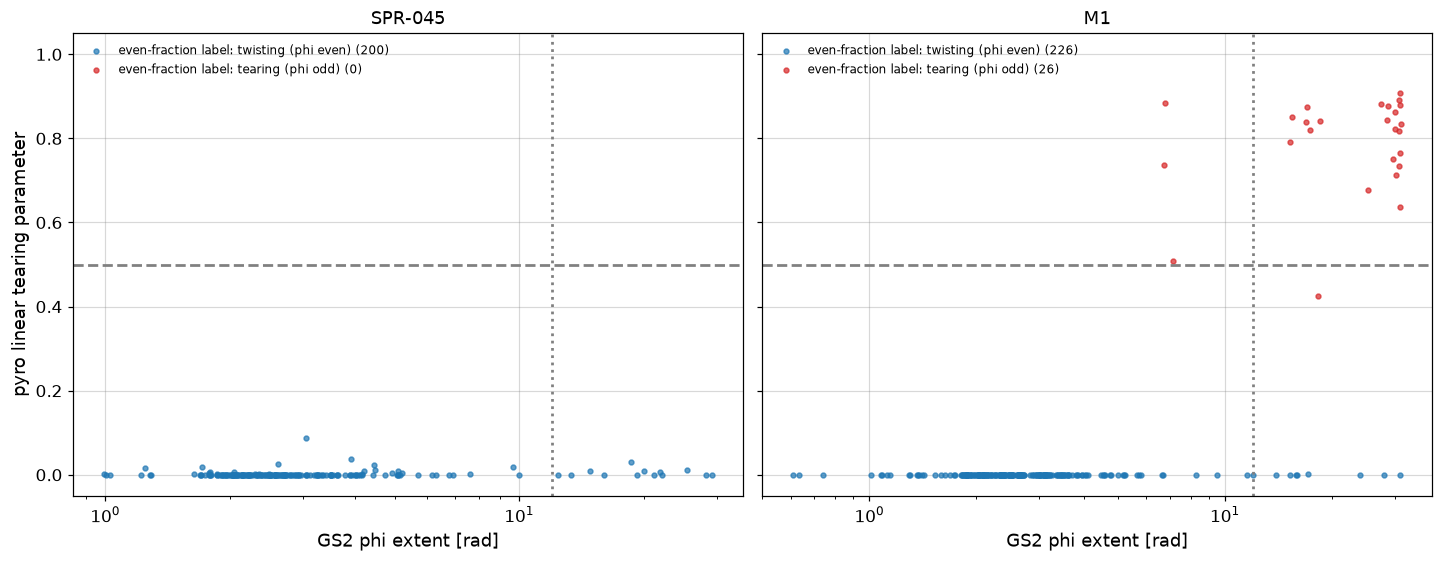

In [ ]:
fig15, axes15 = plt.subplots(1, len(cases), figsize=(13, 5), sharey=True, squeeze=False)
for col, db in enumerate(cases):
    ax = axes15[0, col]
    s = gs2_diag[(gs2_diag.db == db) & (gs2_diag.group != "no extent")]
    for label, colour in (("twisting (phi even)", "C0"), ("tearing (phi odd)", "C3")):
        p = s[s.parity == label]
        ax.scatter(p.ext_phi, p.tearing_parameter, s=10, color=colour, alpha=0.7, label=f"even-fraction label: {label} ({len(p)})")
    ax.axhline(tearing_threshold, color="0.5", ls="--", marker="")
    ax.axvline(extended_threshold, color="0.5", ls=":", marker="")
    ax.set(xscale="log", xlabel="GS2 phi extent [rad]", title=db, ylim=(-0.05, 1.05))
    ax.legend(fontsize=8)
axes15[0, 0].set(ylabel="pyro linear tearing parameter")
plt.show()

In [ ]:
fig15.savefig(ROOT / "Plots" / analysis_name / "fig15_tearing_parameter_vs_gs2_extent.png")

## Extended GS2 modes: interpretation

**Most extended GS2 modes are not well-resolved KBMs.**

- **M1 (31 extended): mostly microtearing-like.** 23 of 31 have tearing parity (phi odd, apar even; compact M1 modes
  are essentially all twisting parity), all 23 have omega < 0 (opposite sign to 89% of compact M1 modes), and apar carries
  ~90-100% of their heat flux (compact median ~0). That is the microtearing signature, not KBM. 21 of the 23 have a
  converged GS2 growth rate but have not decayed at GS2's +-5 pi box edge (edge |phi| up to 1.0 of the peak), so they
  are truncated in ballooning space and their extents are lower bounds. Of the 8 twisting-parity cases, 4 are also at
  the box edge; the 4 that decay inside the box (iteration_2, 67, 207, 236) include one at beta ~ 0 (207, electrostatic)
  and three with omega > 0 and little apar heat flux, so not clear KBMs either.
- **SPR-045 (13 extended): unconverged, near-marginal runs.** All have twisting parity, but none meets the GS2
  convergence threshold (`growth_rate_tolerance` median 1.3, up to 33, vs 0.02 for compact modes) and growth rates are
  near marginal (median 0.012; iteration_19 has omega = -54). 6 of 13 are also at the box edge.
- Both extended groups sit at low magnetic shear (median shat 1.06 M1, 0.19 SPR-045, vs ~2.6-2.7 compact), where
  extended ballooning structure is expected.
- **Consequence for the previous section:** "GFTM misses the extended KBMs" should be read as GFTM (a KBM/ITG-parity
  basis, run with FILTER=0.5 or not) not reproducing GS2's extended **microtearing-like** modes on M1, and disagreeing
  with **unreliable** near-marginal GS2 references on SPR-045. There is no clean sample of converged, box-resolved,
  extended KBMs here to test GFTM on. Settling it needs GS2 reruns of these cases with a longer ballooning box (larger
  nperiod) and tighter convergence.
- Caveats: `gamma_tol_max` and `edge_max` are judgement thresholds (settings above); `growth_rate_tolerance` also flags
  ~30-35% of compact cases, so it is a relative, not absolute, convergence signal. Frequency sign is compared within
  pyro's convention, not mapped to ion/electron direction here.